# Section 1.2.5 — Deuxièmes limites et MCRS

Ce notebook étudie les distributions conditionnelles des deuxièmes limites dans le modèle quatre files :

$$[Q^{+1}, Q^{-1}, Q^{+2}, Q^{-2}].$$

L'objectif scientifique principal n'est pas seulement d'estimer une probabilité de déplétion. Il est d'estimer et de comparer les lois conditionnelles

$$\mathrm{Law}(Q^{-2}\mid Q^{-1}=0),\qquad \mathrm{Law}(Q^{-2}\mid Q^{+1}=0),$$

afin de mesurer l'effet de l'excitation croisée sur la deuxième limite bid.

## 1.2.5.0 — MCRS : méthode, loi conditionnelle de S et diagnostics

Cette partie regroupe la conception de l'estimateur : convention de signe, état markovien $(Q,S)$, collecte frontière, loi conditionnelle de $S$, redémarrages locaux, diagnostics Ogata et comparaison distributionnelle. Les réponses finales aux deux sous-questions du sujet sont ensuite résumées en `1.2.5.1` et `1.2.5.2`.

La méthode utilisée est **Markovian Conditional Restart Splitting** (MCRS). Ogata thinning reste le simulateur bas niveau des trajectoires Hawkes. MCRS ajoute une couche d'estimation rare-event : on collecte des checkpoints proches de la frontière, puis on redémarre localement depuis l'état markovien complet.

La comparaison finale porte donc sur des métriques distributionnelles de $Q^{-2}$, plutôt que seulement sur la largeur d'intervalle de confiance d'un estimateur de Bernoulli.

Cette première partie sert donc de **chapitre méthodologique 1.2.5.0**. Les sections ajoutées à la fin répondent ensuite directement aux questions 1.2.5.1 et 1.2.5.2 du sujet.

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from model.hawkes_4q import FourQueueParams
from model import FourQueueHawkesSimulator
from model.restart_splitting import (
    METHOD_NAME,
    bootstrap_difference_ci,
    bootstrap_mean_ci,
    collect_boundary_states,
    default_hawkes_burn_in,
    local_depletion_target_fn,
    local_recovery_fn,
    multilevel_markovian_restart_splitting,
    plot_conditional_S_marginals,
    plot_conditional_S_pairwise,
    restart_from_boundary_distribution,
    run_naive_boundary_mc,
    run_naive_depletion_monte_carlo,
    summarize_conditional_S,
)
from model.plotting_utils import format_metric_table

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
QUEUE_INDICES = [1, -1, 2, -2]

BASE_CFG = dict(
    mu_plus_1=1.2,
    mu_minus_1=1.5,
    alpha=0.3,
    beta=0.5,
    mu_plus_2=0.8,
    mu_minus_2=0.6,
    b_cross=0.5,
    q1_init=10,
    q_neg1_init=10,
    q2_init=5,
    q_neg2_init=5,
)

A_VALUES = [0.0, 0.2, 0.5, 0.8, 1.2]
DENSE_A_MAX = 3.0
DENSE_N_GRID = 1_000
DENSE_A_VALUES = np.linspace(0.0, DENSE_A_MAX, DENSE_N_GRID)
DENSE_N_BOUNDARY_PATHS = 25
DENSE_N_RESTARTS = 60
DENSE_BOOTSTRAP_REPS = 250
LEVELS = [8, 6, 4, 2, 1, 0]
N_BOUNDARY_PATHS = 300
N_RESTARTS = 1_000
HORIZON_BOUNDARY = 120.0
HORIZON_LOCAL = 25.0
RECOVERY_LEVEL = 2
BOOTSTRAP_REPS = 1_000

BURN_IN = default_hawkes_burn_in(FourQueueHawkesSimulator(FourQueueParams(**BASE_CFG, a_cross=0.0)))

pd.Series({**BASE_CFG, 'burn_in': BURN_IN, 'method': METHOD_NAME}, name='configuration')

mu_plus_1                                          1.2
mu_minus_1                                         1.5
alpha                                              0.3
beta                                               0.5
mu_plus_2                                          0.8
mu_minus_2                                         0.6
b_cross                                            0.5
q1_init                                             10
q_neg1_init                                         10
q2_init                                              5
q_neg2_init                                          5
burn_in                                           50.0
method         Markovian Conditional Restart Splitting
Name: configuration, dtype: object

### 1.2.5.0(a) Convention de signe et état markovien

La convention de signe du code est :

- indice positif : côté ask ;
- indice négatif : côté bid ;
- ordre d'état : $[Q^{+1}, Q^{-1}, Q^{+2}, Q^{-2}]$.

Pour Hawkes exponentiel, la dynamique est markovienne dans l'état augmenté $(N,S)$, où $N$ contient les tailles de files et $S$ l'excitation exponentiellement décayée. Dans le modèle quatre files, le vecteur utilisé ici est

$$
S=(S^{+1,-}, S^{-1,-}, S^{+1,-\to +2,+}, S^{-1,-\to -2,-}).
$$

La composante $S^{-1,-\to -2,-}$ correspond au canal bid demandé ici : les retraits sur $Q^{-1}$ pilotent la réponse de la deuxième limite $Q^{-2}$ dans le checkpoint markovien.

### 1.2.5.0(b) Principe de Markovian Conditional Restart Splitting

MCRS procède en deux étapes.

1. **Collecte frontière.** On simule des trajectoires Ogata jusqu'au premier temps où $Q^{\pm1}=1$. Le checkpoint stocke le temps, les queues, l'intensité, $H$, $G$ et les métadonnées.

2. **Redémarrage conditionnel.** On échantillonne ces checkpoints et on continue localement jusqu'à déplétion, récupération ou timeout. La probabilité locale estimée est

$$
\widehat p=\frac{1}{R}\sum_{r=1}^R
\mathbf 1\{Q^{\pm1}\text{ atteint }0\text{ avant récupération}\}.
$$

Mais en Section 1.2.5, l'objet central est la distribution des valeurs de $Q^{-2}$ au moment des redémarrages réussis.

### 1.2.5.0(c) Interprétation théorique des indicateurs

- `success_probability` : probabilité empirique qu'après redémarrage depuis $Q^{\pm1}=1$, la trajectoire atteigne $Q^{\pm1}=0$ avant récupération. Formule : $\widehat p=R^{-1}\sum_r \mathbf 1_{\{\tau_0<\tau_{rec}\}}$.
- `recovery_probability` : probabilité que la trajectoire s'éloigne de la frontière, par exemple $Q^{\pm1}\ge$ `recovery_level`, avant d'atteindre zéro.
- `timeout_probability` : probabilité que ni déplétion ni récupération ne se produise avant `HORIZON_LOCAL`; si elle est grande, l'horizon local est trop court.
- `std_error_success` : erreur standard Bernoulli $\sqrt{\widehat p(1-\widehat p)/R}$. Si $\widehat p=1$, elle vaut zéro et ne mesure pas l'incertitude distributionnelle.
- `mean_Q-2_success` : estimateur de $\mathbb E[Q^{-2}\mid$ déplétion locale réussie$]$, l'objet central de cette section.
- `bootstrap CI` : intervalle obtenu par rééchantillonnage des valeurs réussies de $Q^{-2}$; il est plus pertinent qu'un IC Bernoulli lorsque $\widehat p$ est dégénéré.
- `effective_sample_size` : nombre effectif d'échantillons indépendants représentés par le schéma de rééchantillonnage.
- `checkpoint_usage_ess` : diagnostic de diversité des checkpoints; si quelques checkpoints sont trop réutilisés, l'ESS devient petit.
- `acceptance_candidate_ratio` : efficacité d'Ogata, égale à `accepted_events / candidate_events`.
- `cpu_seconds` : coût mur en secondes.
- `ESS_per_second` : efficacité computationnelle, `effective_sample_size / cpu_seconds`.
- `n_events` et `n_candidates` : proxys indépendants du matériel pour mesurer le coût de simulation.
- `avg_local_time` : temps simulé moyen après redémarrage avant déplétion, récupération ou timeout.
- `a_cross` : amplitude de l'excitation des arrivées en deuxième limite par les retraits en première limite; l'augmenter doit déplacer $Q^{-2}_{same}$ vers la droite.
- `burn_in` : période préliminaire qui réduit les effets de bord en laissant les excitations Hawkes se rapprocher d'un régime stationnaire.
- `levels` : niveaux de splitting $Q=10\to8\to6\to4\to2\to1\to0$; le produit des probabilités conditionnelles estime la probabilité d'atteindre zéro.

**cpu_seconds_per_sample et cpu_seconds_per_effective_sample.** Ces ratios mesurent le coût moyen par échantillon brut et par échantillon effectif. Le second est plus sévère pour MCRS, car il pénalise la réutilisation répétée des mêmes checkpoints frontière.

### 1.2.5.0(d) Configuration et paramètres

Le burn-in par défaut est

$$T_{burn}=\frac{10}{\beta(1-\alpha/\beta)}.$$

Avec $\alpha=0.3$ et $\beta=0.5$, on obtient $T_{burn}=50$. Ce burn-in est utilisé pour la collecte frontière principale.

In [2]:
def make_params(a_cross: float, q0: int = 10) -> FourQueueParams:
    return FourQueueParams(
        **dict(BASE_CFG, q1_init=q0, q_neg1_init=q0),
        a_cross=float(a_cross),
    )


def q_label(queue_index: int) -> str:
    return 'Q+1' if queue_index == 1 else 'Q-1'


def resume_distribution(x):
    x = np.asarray(x, dtype=float)
    return pd.Series({
        'n_samples': int(len(x)),
        'mean_Q_minus_2': float(np.mean(x)) if len(x) else np.nan,
        'std_Q_minus_2': float(np.std(x, ddof=1)) if len(x) > 1 else np.nan,
        'q05': float(np.quantile(x, 0.05)) if len(x) else np.nan,
        'median': float(np.quantile(x, 0.50)) if len(x) else np.nan,
        'q95': float(np.quantile(x, 0.95)) if len(x) else np.nan,
    })


def ci_width(ci):
    if ci is None:
        return np.nan
    lo, hi = ci
    return hi - lo if np.isfinite(lo) and np.isfinite(hi) else np.nan


def q_neg2_success_from_result(result):
    return np.asarray(result.observables.get('q_neg2_success', np.empty(0)), dtype=float)


def q_neg2_success(bundle):
    return q_neg2_success_from_result(bundle['result'])


def run_mcrs_side(params, queue_index, seed, n_boundary_paths=N_BOUNDARY_PATHS, n_restarts=N_RESTARTS,
                  horizon_boundary=HORIZON_BOUNDARY, horizon_local=HORIZON_LOCAL, burn_in=BURN_IN):
    simulator = FourQueueHawkesSimulator(params)
    initial_state = [params.q1_init, params.q_neg1_init, params.q2_init, params.q_neg2_init]
    sample = collect_boundary_states(
        simulator=simulator,
        initial_state=initial_state,
        horizon=horizon_boundary,
        n_paths=n_boundary_paths,
        rng=seed,
        burn_in=burn_in,
        queue_index=queue_index,
        boundary_level=1,
        queue_indices=QUEUE_INDICES,
        boundary_name=f'{q_label(queue_index)}=1',
        queue_label=q_label(queue_index),
    )
    result = restart_from_boundary_distribution(
        checkpoints=sample,
        simulator=simulator,
        local_target_fn=local_depletion_target_fn(queue_index),
        recovery_fn=local_recovery_fn(queue_index, RECOVERY_LEVEL),
        horizon_local=horizon_local,
        n_restarts=n_restarts,
        rng=seed + 1_000_003,
        sample_with_replacement=True,
        record_path=False,
    )
    return {'method': METHOD_NAME, 'params': params, 'queue_index': queue_index,
            'simulator': simulator, 'boundary_sample': sample, 'result': result}


def run_naive_boundary_side(params, queue_index, seed, n_paths, horizon_boundary=HORIZON_BOUNDARY,
                            horizon_local=HORIZON_LOCAL, burn_in=BURN_IN):
    simulator = FourQueueHawkesSimulator(params)
    result = run_naive_boundary_mc(
        simulator=simulator,
        initial_state=[params.q1_init, params.q_neg1_init, params.q2_init, params.q_neg2_init],
        queue_index=queue_index,
        horizon=horizon_boundary,
        n_paths=n_paths,
        horizon_local=horizon_local,
        rng=seed,
        boundary_level=1,
        recovery_level=RECOVERY_LEVEL,
        burn_in=burn_in,
        queue_indices=QUEUE_INDICES,
    )
    return {'method': 'Naive Ogata Monte Carlo', 'params': params, 'queue_index': queue_index, 'result': result}


def total_cpu_seconds(obj):
    result = obj['result']
    diag = result.diagnostics
    boundary_meta = diag.get('boundary_metadata', {})
    if 'boundary_sample' in obj:
        boundary_meta = obj['boundary_sample'].metadata
    return float(diag.get('cpu_seconds', 0.0) + boundary_meta.get('cpu_seconds', 0.0))


def total_events_candidates(obj):
    result = obj['result']
    diag = result.diagnostics
    boundary_meta = diag.get('boundary_metadata', {})
    if 'boundary_sample' in obj:
        boundary_meta = obj['boundary_sample'].metadata
    n_events = int(diag.get('n_events', 0) + boundary_meta.get('n_events', 0))
    n_candidates = int(diag.get('n_candidates', 0) + boundary_meta.get('n_candidates', 0))
    return n_events, n_candidates


def effective_sample_size(obj):
    result = obj['result']
    diag = result.diagnostics
    if obj['method'] == 'Naive Ogata Monte Carlo':
        return float(len(q_neg2_success_from_result(result)))
    return float(diag.get('checkpoint_usage_effective_sample_size', np.nan))


def distributional_metrics(obj, side, seed=SEED):
    result = obj['result']
    q = q_neg2_success_from_result(result)
    stats = resume_distribution(q).to_dict()
    mean_ci = bootstrap_mean_ci(q, n_bootstrap=BOOTSTRAP_REPS, rng=seed) if len(q) else (np.nan, np.nan)
    n_events, n_candidates = total_events_candidates(obj)
    cpu = total_cpu_seconds(obj)
    ess = effective_sample_size(obj)
    diag = result.diagnostics
    checkpoint_usage_ess = diag.get('checkpoint_usage_effective_sample_size', np.nan)
    bootstrap_width = mean_ci[1] - mean_ci[0] if np.isfinite(mean_ci[0]) and np.isfinite(mean_ci[1]) else np.nan
    row = {
        'method': obj['method'],
        'side': side,
        'a_cross': getattr(obj.get('params', None), 'a_cross', np.nan),
        **stats,
        'bootstrap_ci_low': mean_ci[0],
        'bootstrap_ci_high': mean_ci[1],
        'bootstrap_ci_width': bootstrap_width,
        'mean_ci_low': mean_ci[0],
        'mean_ci_high': mean_ci[1],
        'bootstrap_CI_width_mean_Q_minus_2': bootstrap_width,
        'effective_sample_size': ess,
        'checkpoint_usage_ess': checkpoint_usage_ess,
        'cpu_seconds': cpu,
        'ESS_per_second': ess / cpu if cpu > 0 else np.nan,
        'cpu_seconds_per_sample': cpu / len(q) if len(q) > 0 else np.nan,
        'cpu_seconds_per_effective_sample': cpu / ess if ess > 0 else np.nan,
        'n_events': n_events,
        'n_candidates': n_candidates,
        'acceptance_candidate_ratio': n_events / n_candidates if n_candidates > 0 else np.nan,
        'success_probability': diag.get('success_probability', result.probability_estimate),
        'recovery_probability': diag.get('recovery_probability', np.nan),
        'timeout_probability': diag.get('timeout_probability', np.nan),
        'avg_local_time': diag.get('average_local_simulation_time', np.nan),
    }
    return row


def conditional_S_table(sample):
    names = sample.metadata.get('S_component_names', [])
    summary = summarize_conditional_S(sample.S_samples, names)
    rows = []
    for j, name in enumerate(names):
        rows.append({
            'component': name,
            'mean': summary['mean'][j],
            'std': summary['std'][j],
            'q05': summary['quantiles'][0.05][j],
            'median': summary['quantiles'][0.50][j],
            'q95': summary['quantiles'][0.95][j],
        })
    return pd.DataFrame(rows).set_index('component') if rows else pd.DataFrame()


def safe_barplot_metric(df, x, y, group=None, title=None, zero_policy='annotate', ylabel=None):
    data = df.copy()
    if data[y].isna().any():
        warnings.warn(f'Missing values in {y}; dropping NaN rows.')
        data = data.dropna(subset=[y])
    fig, ax = plt.subplots(figsize=(12, 4.8))
    if data.empty:
        ax.text(0.5, 0.5, f'No finite values for {y}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return fig, ax
    if np.allclose(data[y].to_numpy(dtype=float), 0.0):
        message = (
            'All CI widths are zero because all estimated probabilities are equal to one.\n'
            'The event is not rare under the current configuration; compare conditional\n'
            'distribution metrics instead.'
        )
        print('Degenerate probability estimator: p=1 for all methods. Switching to distributional comparison.')
        if zero_policy == 'annotate':
            ax.text(0.5, 0.5, message, ha='center', va='center', wrap=True, transform=ax.transAxes)
            ax.set_title(title or y)
            ax.set_axis_off()
            return fig, ax
    labels = data[x].astype(str) if group is None else data[x].astype(str) + ' | ' + data[group].astype(str)
    bars = ax.bar(labels, data[y].to_numpy(dtype=float), color='tab:blue')
    ax.set_title(title or y)
    ax.set_ylabel(ylabel or y)
    if max(len(str(label)) for label in labels) > 12:
        ax.tick_params(axis='x', rotation=20)
    for bar, value in zip(bars, data[y]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3g}', ha='center', va='bottom')
    fig.tight_layout()
    return fig, ax


def joint_distribution_plot(x, y, hue=None, kind='hexbin', title=None, xlabel=None, ylabel=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    fig, ax = plt.subplots(figsize=(8, 5))
    if len(x) == 0:
        ax.text(0.5, 0.5, 'No paired finite samples', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return fig, ax
    corr = np.corrcoef(x, y)[0, 1] if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    if hue is None:
        if kind == 'hexbin' and len(x) >= 300:
            hb = ax.hexbin(x, y, gridsize=28, mincnt=1, cmap='viridis')
            fig.colorbar(hb, ax=ax, label='count')
        else:
            ax.scatter(x, y, alpha=0.55, s=20)
    else:
        hue = np.asarray(hue)[mask]
        for label in pd.unique(hue):
            m = hue == label
            ax.scatter(x[m], y[m], alpha=0.35, s=16, label=str(label))
        ax.legend()
    ax.set_xlabel(xlabel or 'x')
    ax.set_ylabel(ylabel or 'y')
    ax.set_title((title or 'Joint distribution') + f' | corr={corr:.3f}' if np.isfinite(corr) else (title or 'Joint distribution'))
    fig.tight_layout()
    return fig, ax


def restart_content_table(obj, n=8):
    result = obj['result']
    obs = result.observables
    names = obj.get('boundary_sample', {}).metadata.get('S_component_names', []) if 'boundary_sample' in obj else []
    rows = []
    for k in range(min(n, len(obs['success']))):
        row = {
            'restart': k,
            'outcome': obs.get('outcome', np.array([''] * len(obs['success'])))[k],
            'local_time': obs['local_times'][k],
            'start_Q+1': obs['start_queues'][k, 0],
            'start_Q-1': obs['start_queues'][k, 1],
            'start_Q-2': obs['start_queues'][k, 3],
            'final_Q+1': obs['final_queues'][k, 0],
            'final_Q-1': obs['final_queues'][k, 1],
            'final_Q-2': obs['final_queues'][k, 3],
        }
        for j, name in enumerate(names):
            row[f'start {name}'] = obs['start_S'][k, j]
            row[f'end {name}'] = obs['end_S'][k, j]
        rows.append(row)
    return pd.DataFrame(rows)


def display_fr(text):
    display(Markdown(text))


### 1.2.5.0(e) Collecte des checkpoints frontière avec burn-in

On commence par collecter des états frontière avec $a_{cross}=0.5$. La frontière $Q^{-1}=1$ sert à étudier le côté same-side bid; la frontière $Q^{+1}=1$ sert de comparaison opposite-side pour $Q^{-2}$.

In [3]:
params_ref = make_params(a_cross=0.5)
ref_same = run_mcrs_side(params_ref, queue_index=-1, seed=SEED + 10)
ref_opp = run_mcrs_side(params_ref, queue_index=1, seed=SEED + 20)

boundary_table = pd.DataFrame([
    {
        'side': 'Q-1=1 boundary',
        'n_paths': ref_same['boundary_sample'].metadata['n_paths'],
        'n_boundary_samples': ref_same['boundary_sample'].metadata['n_boundary_hits'],
        'boundary_hit_rate': ref_same['boundary_sample'].metadata['boundary_hit_rate'],
        'burn_in': ref_same['boundary_sample'].metadata['burn_in'],
        'cpu_seconds': ref_same['boundary_sample'].metadata['cpu_seconds'],
        'n_events': ref_same['boundary_sample'].metadata['n_events'],
        'n_candidates': ref_same['boundary_sample'].metadata['n_candidates'],
    },
    {
        'side': 'Q+1=1 boundary',
        'n_paths': ref_opp['boundary_sample'].metadata['n_paths'],
        'n_boundary_samples': ref_opp['boundary_sample'].metadata['n_boundary_hits'],
        'boundary_hit_rate': ref_opp['boundary_sample'].metadata['boundary_hit_rate'],
        'burn_in': ref_opp['boundary_sample'].metadata['burn_in'],
        'cpu_seconds': ref_opp['boundary_sample'].metadata['cpu_seconds'],
        'n_events': ref_opp['boundary_sample'].metadata['n_events'],
        'n_candidates': ref_opp['boundary_sample'].metadata['n_candidates'],
    },
])
display(boundary_table)

display_fr(
    f"""
**Interprétation.** Les deux collectes utilisent un burn-in de {BURN_IN:.0f}. 
On obtient {int(boundary_table.loc[0, 'n_boundary_samples'])} checkpoints bid et {int(boundary_table.loc[1, 'n_boundary_samples'])} checkpoints ask.
Le taux d'atteinte frontière vaut respectivement {boundary_table.loc[0, 'boundary_hit_rate']:.3f} et {boundary_table.loc[1, 'boundary_hit_rate']:.3f}.
Ces checkpoints forment l'approximation empirique de $Law(S\\mid Q^{{-1}}=1)$ et $Law(S\\mid Q^{{+1}}=1)$.
"""
)


,side,n_paths,n_boundary_samples,boundary_hit_rate,burn_in,cpu_seconds,n_events,n_candidates
0,Q-1=1 boundary,300,300,1.0,50.0,2.274728,1083,1108
1,Q+1=1 boundary,300,300,1.0,50.0,1.847823,1410,1449



**Interprétation.** Les deux collectes utilisent un burn-in de 50. 
On obtient 300 checkpoints bid et 300 checkpoints ask.
Le taux d'atteinte frontière vaut respectivement 1.000 et 1.000.
Ces checkpoints forment l'approximation empirique de $Law(S\mid Q^{-1}=1)$ et $Law(S\mid Q^{+1}=1)$.


### 1.2.5.0(f) Loi conditionnelle de S à la frontière

Les tableaux et cartes de chaleur suivants décrivent la loi conditionnelle empirique de l'excitation Hawkes au voisinage de la déplétion. Ils permettent de vérifier que les redémarrages conservent bien la mémoire Hawkes.

mean       std       q05    median  \
               component                                                  
Law(S | Q-1=1) S^{+1,-}          1.515757  0.775656  0.304396  1.475860   
               S^{-1,-}          1.701139  0.696575  0.713355  1.651115   
               S^{+1,- -> +2,+}  1.279093  0.615587  0.480615  1.199732   
               S^{-1,- -> -2,+}  1.401655  0.686404  0.434878  1.304557   
Law(S | Q+1=1) S^{+1,-}          1.757045  0.684875  0.668410  1.745146   
               S^{-1,-}          1.593878  0.799328  0.435685  1.523019   
               S^{+1,- -> +2,+}  1.493515  0.748092  0.509738  1.399453   
               S^{-1,- -> -2,+}  1.298921  0.576141  0.412945  1.299347   

                                      q95  
               component                   
Law(S | Q-1=1) S^{+1,-}          2.784230  
               S^{-1,-}          2.863328  
               S^{+1,- -> +2,+}  2.340151  
               S^{-1,- -> -2,+}  2.532080  
Law(S | Q+1=1) S^{+1,-}          2.896362  
               S^{-1,-}          3.082836  
               S^{+1,- -> +2,+}  2.803117  
               S^{-1,- -> -2,+}  2.287925

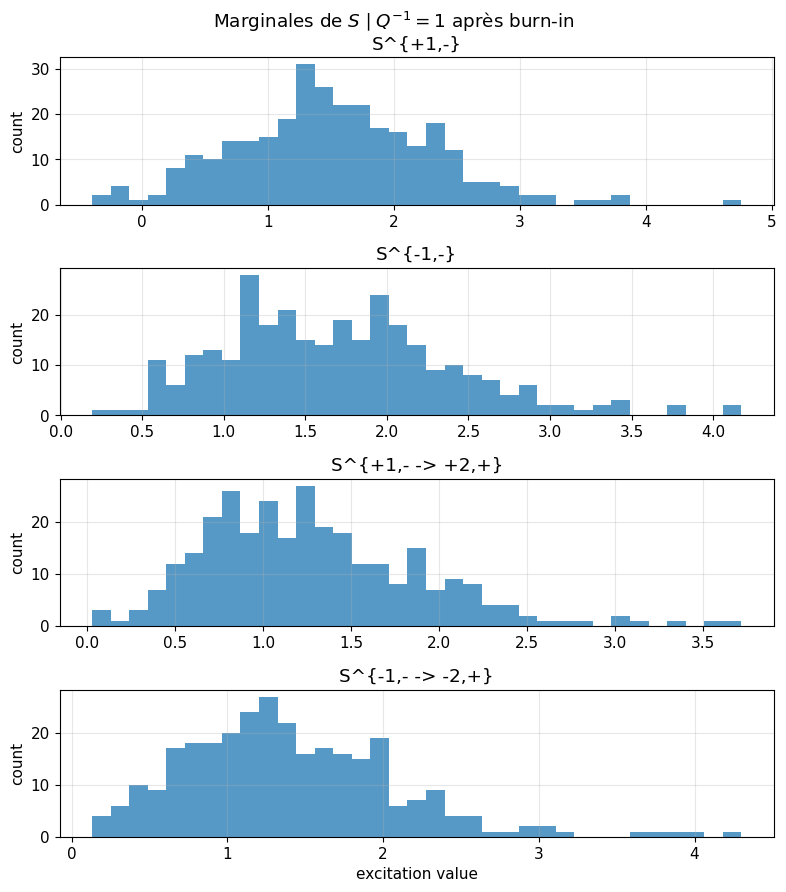

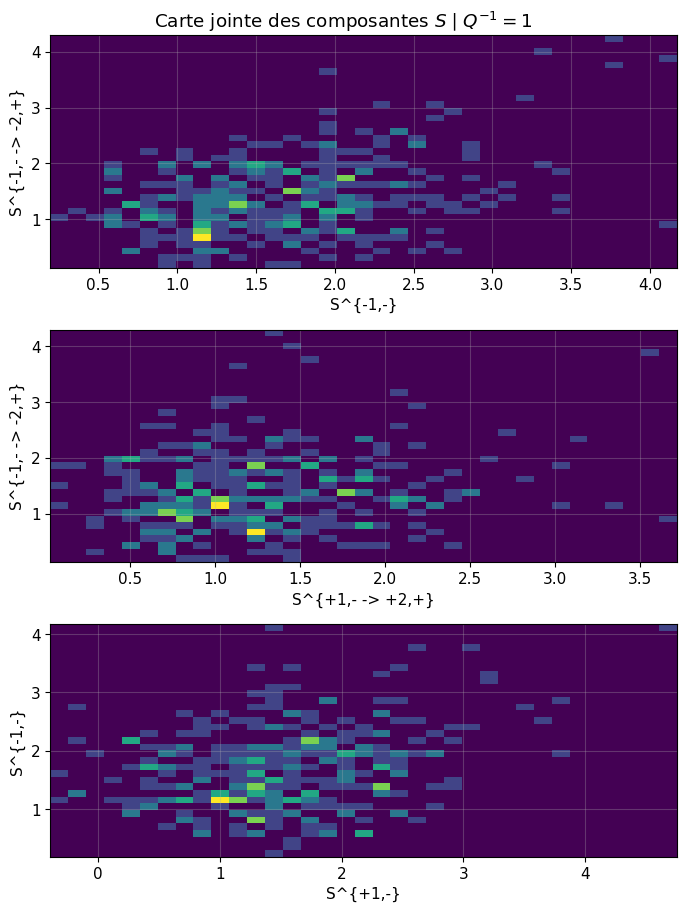


**Interprétation de la loi jointe de S.** Ce graphique montre la relation empirique entre les excitations de première limite et les composantes de replenishment de deuxième limite.
Pour $Q^{-1}=1$, la moyenne de $S^{-1,-	o -2,-}$ vaut 1.402 et son quantile 95 % vaut 2.532.
Pour $Q^{+1}=1$, la moyenne ask $S^{+1,-	o +2,+}$ vaut 1.494.
Une masse importante dans la composante bid indique que les retraits récents de $Q^{-1}$ ont déjà activé l'arrivée sur $Q^{-2}$ avant le redémarrage.


In [4]:
S_same_table = conditional_S_table(ref_same['boundary_sample'])
S_opp_table = conditional_S_table(ref_opp['boundary_sample'])
display(pd.concat({'Law(S | Q-1=1)': S_same_table, 'Law(S | Q+1=1)': S_opp_table}))

names_same = ref_same['boundary_sample'].metadata['S_component_names']
fig, _ = plot_conditional_S_marginals(ref_same['boundary_sample'].S_samples, names_same, bins=35)
fig.suptitle(r'Marginales de $S\mid Q^{-1}=1$ après burn-in', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    ref_same['boundary_sample'].S_samples,
    names_same,
    pairs=[(1, 3), (2, 3), (0, 1)],
    bins=35,
)
fig.suptitle(r'Carte jointe des composantes $S\mid Q^{-1}=1$', y=1.01)
plt.show()

bid_cross_mean = S_same_table.loc['S^{-1,- -> -2,+}', 'mean']
bid_cross_q95 = S_same_table.loc['S^{-1,- -> -2,+}', 'q95']
ask_cross_mean = S_opp_table.loc['S^{+1,- -> +2,+}', 'mean']

display_fr(
    f"""
**Interprétation de la loi jointe de S.** Ce graphique montre la relation empirique entre les excitations de première limite et les composantes de replenishment de deuxième limite.
Pour $Q^{{-1}}=1$, la moyenne de $S^{{-1,-\to -2,-}}$ vaut {bid_cross_mean:.3f} et son quantile 95 % vaut {bid_cross_q95:.3f}.
Pour $Q^{{+1}}=1$, la moyenne ask $S^{{+1,-\to +2,+}}$ vaut {ask_cross_mean:.3f}.
Une masse importante dans la composante bid indique que les retraits récents de $Q^{{-1}}$ ont déjà activé l'arrivée sur $Q^{{-2}}$ avant le redémarrage.
"""
)


### 1.2.5.0(g) Diagnostic burn-in

Pour vérifier l'effet du burn-in, on compare la loi de $S$ à la frontière $Q^{-1}=1$ avec et sans période préliminaire. Le modèle n'est pas modifié; seul l'état initial de l'excitation Hawkes change.

In [5]:
no_burn_sample = collect_boundary_states(
    simulator=FourQueueHawkesSimulator(params_ref),
    initial_state=[params_ref.q1_init, params_ref.q_neg1_init, params_ref.q2_init, params_ref.q_neg2_init],
    horizon=HORIZON_BOUNDARY,
    n_paths=200,
    rng=SEED + 303,
    burn_in=0.0,
    queue_index=-1,
    boundary_level=1,
    queue_indices=QUEUE_INDICES,
    boundary_name='Q-1=1 no burn-in',
    queue_label='Q-1',
)

burn_compare = pd.DataFrame({
    'no_burn_in_mean': conditional_S_table(no_burn_sample)['mean'],
    'burn_in_50_mean': conditional_S_table(ref_same['boundary_sample'])['mean'],
    'no_burn_in_std': conditional_S_table(no_burn_sample)['std'],
    'burn_in_50_std': conditional_S_table(ref_same['boundary_sample'])['std'],
})
burn_compare['mean_shift'] = burn_compare['burn_in_50_mean'] - burn_compare['no_burn_in_mean']
display(burn_compare)

cross_name = 'S^{-1,- -> -2,+}'
shift = burn_compare.loc[cross_name, 'mean_shift']
std_ratio = burn_compare.loc[cross_name, 'burn_in_50_std'] / burn_compare.loc[cross_name, 'no_burn_in_std']
display_fr(
    f"""
**Interprétation du burn-in.** Pour la composante bid {cross_name}, le burn-in déplace la moyenne de {burn_compare.loc[cross_name, 'no_burn_in_mean']:.3f} à {burn_compare.loc[cross_name, 'burn_in_50_mean']:.3f}, soit un écart de {shift:.3f}.
Le ratio d'écart-type burn-in / sans burn-in vaut {std_ratio:.3f}.
Cela confirme que la loi frontière de $S$ dépend de l'initialisation Hawkes; utiliser un burn-in réduit l'effet artificiel de partir de $H=G=0$.
"""
)


,no_burn_in_mean,burn_in_50_mean,no_burn_in_std,burn_in_50_std,mean_shift
component,,,,,
"S^{+1,-}",3.762202,1.515757,1.008041,0.775656,-2.246444
"S^{-1,-}",3.974380,1.701139,0.797908,0.696575,-2.273240
"S^{+1,- -> +2,+}",2.676130,1.279093,0.938637,0.615587,-1.397037
"S^{-1,- -> -2,+}",3.771021,1.401655,0.728193,0.686404,-2.369366



**Interprétation du burn-in.** Pour la composante bid S^{-1,- -> -2,+}, le burn-in déplace la moyenne de 3.771 à 1.402, soit un écart de -2.369.
Le ratio d'écart-type burn-in / sans burn-in vaut 0.943.
Cela confirme que la loi frontière de $S$ dépend de l'initialisation Hawkes; utiliser un burn-in réduit l'effet artificiel de partir de $H=G=0$.


### 1.2.5.0(h) Expérience de redémarrage local

Depuis chaque checkpoint frontière, on redémarre localement jusqu'à l'un des trois événements : déplétion, récupération ou timeout. Les probabilités doivent sommer à un, et le timeout doit rester faible.

In [6]:
restart_table = pd.DataFrame([
    distributional_metrics(ref_same, 'Q-2 | Q-1=0 same-side', seed=SEED + 101),
    distributional_metrics(ref_opp, 'Q-2 | Q+1=0 opposite-side', seed=SEED + 102),
])
display(restart_table[[
    'side', 'success_probability', 'recovery_probability', 'timeout_probability',
    'n_samples', 'mean_Q_minus_2', 'std_Q_minus_2', 'q05', 'median', 'q95',
    'bootstrap_CI_width_mean_Q_minus_2', 'effective_sample_size', 'cpu_seconds',
    'ESS_per_second', 'acceptance_candidate_ratio', 'avg_local_time'
]])

display(restart_content_table(ref_same, n=8))

for obj in [ref_same, ref_opp]:
    result = obj['result']
    obs = result.observables
    probs = np.array([
        result.diagnostics['success_probability'],
        result.diagnostics['recovery_probability'],
        result.diagnostics['timeout_probability'],
    ])
    assert np.all(obs['start_queues'] >= 0) and np.all(obs['final_queues'] >= 0)
    assert np.isclose(probs.sum(), 1.0, atol=1e-12)
    assert 0.0 <= result.diagnostics['acceptance_candidate_ratio'] <= 1.0
    assert result.diagnostics['checkpoint_usage_effective_sample_size'] <= result.n_restarts
    assert result.diagnostics['timeout_probability'] <= 0.05
    ci = bootstrap_mean_ci(q_neg2_success(obj), rng=SEED)
    assert ci[1] >= ci[0]

display_fr(
    f"""
**Interprétation des redémarrages.** La probabilité de succès locale vaut {restart_table.loc[0, 'success_probability']:.3f} côté same-side et {restart_table.loc[1, 'success_probability']:.3f} côté opposite-side.
Les probabilités de timeout sont {restart_table.loc[0, 'timeout_probability']:.3f} et {restart_table.loc[1, 'timeout_probability']:.3f}, donc l'horizon local {HORIZON_LOCAL:.0f} est suffisant.
L'ESS des checkpoints vaut {restart_table.loc[0, 'effective_sample_size']:.1f} et {restart_table.loc[1, 'effective_sample_size']:.1f}; il mesure la diversité réelle des états frontière utilisés.
"""
)


,side,success_probability,recovery_probability,timeout_probability,n_samples,mean_Q_minus_2,std_Q_minus_2,q05,median,q95,bootstrap_CI_width_mean_Q_minus_2,effective_sample_size,cpu_seconds,ESS_per_second,acceptance_candidate_ratio,avg_local_time
0,Q-2 | Q-1=0 same-side,0.873,0.127,0.0,873.0,83.126002,13.374550,63.0,82.0,108.4,1.743872,229.252636,2.340291,97.959023,0.973357,0.097967
1,Q-2 | Q+1=0 opposite-side,0.863,0.137,0.0,863.0,82.385863,13.854083,61.0,82.0,104.0,1.884502,230.733733,1.908737,120.882931,0.975968,0.110215


,restart,outcome,local_time,start_Q+1,start_Q-1,start_Q-2,final_Q+1,final_Q-1,final_Q-2,"start S^{+1,-}","end S^{+1,-}","start S^{-1,-}","end S^{-1,-}","start S^{+1,- -> +2,+}","end S^{+1,- -> +2,+}","start S^{-1,- -> -2,+}","end S^{-1,- -> -2,+}"
0,0,success,0.070262,0.0,1.0,84.0,0.0,0.0,84.0,1.621908,1.865918,0.949713,1.216928,0.993412,0.959119,1.149605,1.609919
1,1,recovery,0.353387,2.0,1.0,87.0,3.0,2.0,87.0,1.517365,1.305780,1.373082,1.116520,1.114973,0.934388,1.293733,1.084195
2,2,success,0.000000,1.0,0.0,95.0,1.0,0.0,95.0,0.213552,0.213552,1.776437,1.776437,1.444715,1.444715,0.213609,0.213609
3,3,success,0.454410,0.0,1.0,110.0,0.0,0.0,110.0,0.988172,1.087333,1.196910,1.253647,1.179839,0.940046,0.641062,1.010771
4,4,success,0.000000,4.0,0.0,89.0,4.0,0.0,89.0,0.296093,0.296093,2.226333,2.226333,0.946840,0.946840,1.155181,1.155181
5,5,success,0.062381,1.0,1.0,94.0,1.0,0.0,95.0,2.020642,2.258590,2.322024,2.550716,1.618577,1.568872,2.000311,2.438883
6,6,success,0.000000,2.0,0.0,88.0,2.0,0.0,88.0,0.153639,0.153639,1.147067,1.147067,0.291460,0.291460,0.792462,0.792462
7,7,success,0.000000,2.0,0.0,71.0,2.0,0.0,71.0,0.541668,0.541668,1.760499,1.760499,0.897611,0.897611,1.020862,1.020862



**Interprétation des redémarrages.** La probabilité de succès locale vaut 0.873 côté same-side et 0.863 côté opposite-side.
Les probabilités de timeout sont 0.000 et 0.000, donc l'horizon local 25 est suffisant.
L'ESS des checkpoints vaut 229.3 et 230.7; il mesure la diversité réelle des états frontière utilisés.


### 1.2.5.0(i) Distribution de Q^{-2} au succès local

On analyse maintenant les distributions conditionnelles de $Q^{-2}$ au moment où le redémarrage réussit.

,n_samples,mean_Q_minus_2,std_Q_minus_2,q05,median,q95
Q-2_same = Q-2 | Q-1=0,873.0,83.126002,13.374550,63.0,82.0,108.4
Q-2_opp = Q-2 | Q+1=0,863.0,82.385863,13.854083,61.0,82.0,104.0


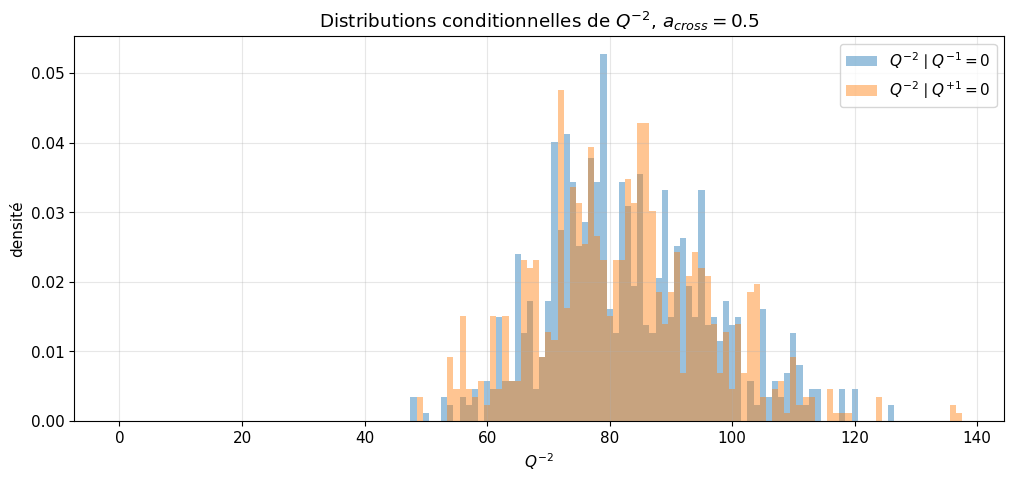


**Interprétation distributionnelle.** La moyenne same-side vaut 83.13 avec IC bootstrap [82.23, 84.04], tandis que la moyenne opposite-side vaut 82.39 avec IC [81.41, 83.22].
Les médianes sont 82.0 et 82.0; les quantiles 95 % sont 108.4 et 104.0.
Les intervalles se recouvrent, ce qui rend l effet statistiquement moins net.
Lorsque $a_{cross}>0$, on s'attend à un déplacement vers la droite du côté same-side si le canal $Q^{-1}	o Q^{-2}$ domine.


In [7]:
q_same_ref = q_neg2_success(ref_same)
q_opp_ref = q_neg2_success(ref_opp)
q2_ref_table = pd.DataFrame({
    'Q-2_same = Q-2 | Q-1=0': resume_distribution(q_same_ref),
    'Q-2_opp = Q-2 | Q+1=0': resume_distribution(q_opp_ref),
}).T
display(q2_ref_table)

max_value = int(max(q_same_ref.max(), q_opp_ref.max(), 10))
bins = np.arange(-0.5, max_value + 1.5, 1)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(q_same_ref, bins=bins, density=True, alpha=0.45, label=r'$Q^{-2}\mid Q^{-1}=0$')
ax.hist(q_opp_ref, bins=bins, density=True, alpha=0.45, label=r'$Q^{-2}\mid Q^{+1}=0$')
ax.set_xlabel(r'$Q^{-2}$')
ax.set_ylabel('densité')
ax.set_title(r'Distributions conditionnelles de $Q^{-2}$, $a_{cross}=0.5$')
ax.legend()
plt.show()

same_ci = bootstrap_mean_ci(q_same_ref, rng=SEED + 201)
opp_ci = bootstrap_mean_ci(q_opp_ref, rng=SEED + 202)
overlap = not (same_ci[0] > opp_ci[1] or opp_ci[0] > same_ci[1])
display_fr(
    f"""
**Interprétation distributionnelle.** La moyenne same-side vaut {q_same_ref.mean():.2f} avec IC bootstrap [{same_ci[0]:.2f}, {same_ci[1]:.2f}], tandis que la moyenne opposite-side vaut {q_opp_ref.mean():.2f} avec IC [{opp_ci[0]:.2f}, {opp_ci[1]:.2f}].
Les médianes sont {np.median(q_same_ref):.1f} et {np.median(q_opp_ref):.1f}; les quantiles 95 % sont {np.quantile(q_same_ref, 0.95):.1f} et {np.quantile(q_opp_ref, 0.95):.1f}.
Les intervalles {'se recouvrent' if overlap else 'ne se recouvrent pas'}, ce qui {'rend l effet statistiquement moins net' if overlap else 'rend l effet visible au niveau des moyennes'}.
Lorsque $a_{{cross}}>0$, on s'attend à un déplacement vers la droite du côté same-side si le canal $Q^{{-1}}\to Q^{{-2}}$ domine.
"""
)


### 1.2.5.0(j) Analyse des distributions jointes

On visualise maintenant plusieurs relations jointes : excitation initiale versus $Q^{-2}$ final, distribution paired same/opposite, et sensibilité conjointe en $a_{cross}$.

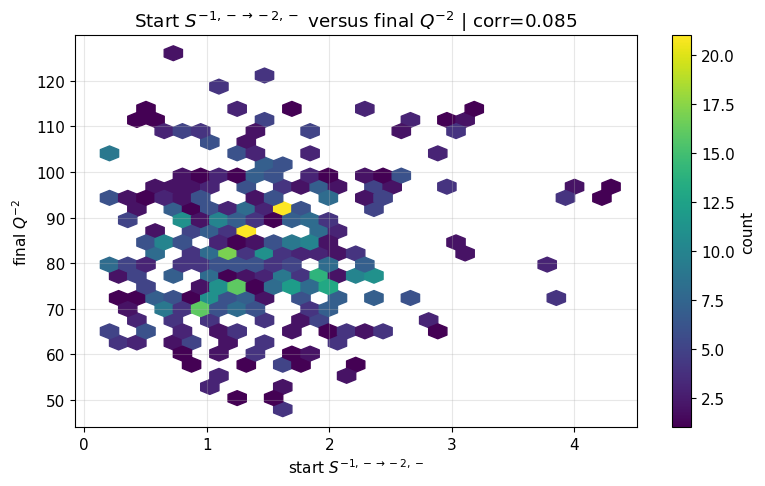


**Interprétation du nuage excitation--Q2.** Ce graphique montre la relation empirique entre l'excitation croisée bid au redémarrage et la taille finale de $Q^{-2}$.
Sur les redémarrages réussis, la corrélation empirique vaut 0.061.
Si le nuage est horizontal, cela suggère que l'excitation de départ est rapidement dominée par les événements ultérieurs; une pente positive indiquerait que la mémoire Hawkes initiale se transmet directement à $Q^{-2}$.
Ici, l'effet doit être lu conjointement avec la distribution de $Q^{-2}$ et la sensibilité en $a_{cross}$.


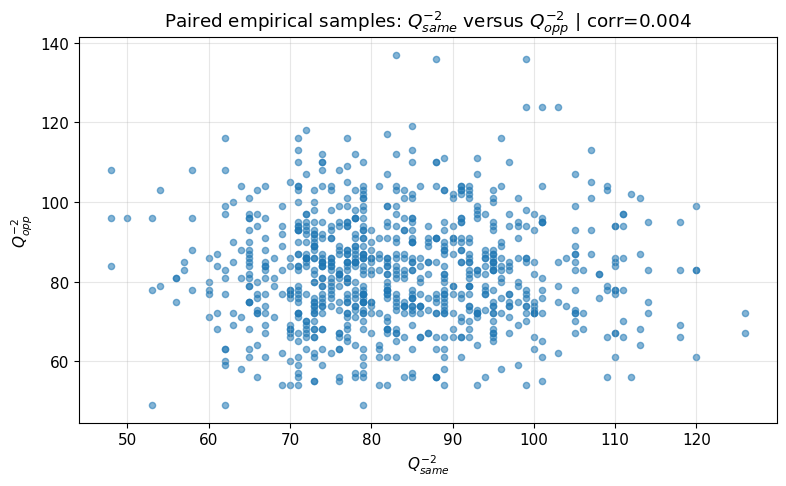


**Interprétation same/opposite appariée.** Ce graphique apparie les 863 premiers échantillons réussis des deux lois conditionnelles afin de comparer leurs ordres de grandeur.
La moyenne same-side est 83.13; la moyenne opposite-side est 82.39.
Si les points étaient concentrés autour de la diagonale, les deux lois seraient proches; un déplacement systématique vers la droite indique une taille same-side plus élevée.
L'appariement est seulement descriptif, car les deux séries proviennent de redémarrages indépendants.


In [8]:
obs_same = ref_same['result'].observables
names = ref_same['boundary_sample'].metadata['S_component_names']
cross_idx = names.index('S^{-1,- -> -2,+}')
fig, ax = joint_distribution_plot(
    obs_same['start_S'][:, cross_idx],
    obs_same['final_queues'][:, 3],
    kind='hexbin',
    title=r'Start $S^{-1,-\to -2,-}$ versus final $Q^{-2}$',
    xlabel=r'start $S^{-1,-\to -2,-}$',
    ylabel=r'final $Q^{-2}$',
)
plt.show()

successful = obs_same['success']
corr_success = np.corrcoef(obs_same['start_S'][successful, cross_idx], obs_same['final_queues'][successful, 3])[0, 1]
display_fr(
    f"""
**Interprétation du nuage excitation--Q2.** Ce graphique montre la relation empirique entre l'excitation croisée bid au redémarrage et la taille finale de $Q^{{-2}}$.
Sur les redémarrages réussis, la corrélation empirique vaut {corr_success:.3f}.
Si le nuage est horizontal, cela suggère que l'excitation de départ est rapidement dominée par les événements ultérieurs; une pente positive indiquerait que la mémoire Hawkes initiale se transmet directement à $Q^{{-2}}$.
Ici, l'effet doit être lu conjointement avec la distribution de $Q^{{-2}}$ et la sensibilité en $a_{{cross}}$.
"""
)

m = min(len(q_same_ref), len(q_opp_ref))
fig, ax = joint_distribution_plot(
    q_same_ref[:m],
    q_opp_ref[:m],
    kind='scatter',
    title=r'Paired empirical samples: $Q^{-2}_{same}$ versus $Q^{-2}_{opp}$',
    xlabel=r'$Q^{-2}_{same}$',
    ylabel=r'$Q^{-2}_{opp}$',
)
plt.show()

display_fr(
    f"""
**Interprétation same/opposite appariée.** Ce graphique apparie les {m} premiers échantillons réussis des deux lois conditionnelles afin de comparer leurs ordres de grandeur.
La moyenne same-side est {q_same_ref.mean():.2f}; la moyenne opposite-side est {q_opp_ref.mean():.2f}.
Si les points étaient concentrés autour de la diagonale, les deux lois seraient proches; un déplacement systématique vers la droite indique une taille same-side plus élevée.
L'appariement est seulement descriptif, car les deux séries proviennent de redémarrages indépendants.
"""
)


### 1.2.5.0(k) Sensibilité exploratoire dense de $Q^{-2}$ à $a_{cross}$

On remplace ici le balayage grossier par une grille uniforme de 1000 points :

$$
a_{cross}\in[0,3.0], \qquad a_i = \frac{3.0 i}{999}, \quad i=0,\ldots,999.
$$

Cette section est un **diagnostic de forme** : pour garder le notebook exécutable, chaque point de la grille utilise un budget MCRS plus léger que les tableaux finaux de `1.2.5.1` et `1.2.5.2`. Pour chaque valeur de $a$, on estime

$$
\Delta(a)=\mathbb E[Q^{-2}\mid Q^{-1}=0]-\mathbb E[Q^{-2}\mid Q^{+1}=0].
$$

On résume ensuite la trajectoire empirique $a\mapsto\Delta(a)$ par sa moyenne, sa variance et sa distribution sur les 1000 points de grille. La variance bootstrap de $\Delta(a)$ mesure l'incertitude Monte Carlo locale pour un $a$ fixé, tandis que la variance sur la grille mesure la variabilité de la fonction estimée quand $a$ varie.

In [9]:
def bootstrap_difference_draws(left, right, n_bootstrap=DENSE_BOOTSTRAP_REPS, rng=SEED):
    """Bootstrap draws of mean(left) - mean(right), used to study Delta(a)."""
    x = np.asarray(left, dtype=float)
    y = np.asarray(right, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.empty(0, dtype=float)
    rng_obj = np.random.default_rng(rng)
    x_draws = rng_obj.choice(x, size=(int(n_bootstrap), len(x)), replace=True).mean(axis=1)
    y_draws = rng_obj.choice(y, size=(int(n_bootstrap), len(y)), replace=True).mean(axis=1)
    return x_draws - y_draws


def dense_side_metrics(obj, side, seed):
    """Lightweight distributional metrics for the 200-point exploratory sweep."""
    result = obj['result']
    q = q_neg2_success_from_result(result)
    stats = resume_distribution(q).to_dict()
    mean_ci = bootstrap_mean_ci(q, n_bootstrap=DENSE_BOOTSTRAP_REPS, rng=seed) if len(q) else (np.nan, np.nan)
    n_events, n_candidates = total_events_candidates(obj)
    cpu = total_cpu_seconds(obj)
    diag = result.diagnostics
    return {
        'method': obj['method'],
        'side': side,
        'a_cross': obj['params'].a_cross,
        **stats,
        'variance_Q_minus_2': float(np.var(q, ddof=1)) if len(q) > 1 else np.nan,
        'bootstrap_ci_low': mean_ci[0],
        'bootstrap_ci_high': mean_ci[1],
        'mean_ci_low': mean_ci[0],
        'mean_ci_high': mean_ci[1],
        'n_events': n_events,
        'n_candidates': n_candidates,
        'acceptance_candidate_ratio': n_events / n_candidates if n_candidates > 0 else np.nan,
        'success_probability': diag.get('success_probability', result.probability_estimate),
        'recovery_probability': diag.get('recovery_probability', np.nan),
        'timeout_probability': diag.get('timeout_probability', np.nan),
        'checkpoint_usage_ess': diag.get('checkpoint_usage_effective_sample_size', np.nan),
        'cpu_seconds': cpu,
    }


sensitivity_rows = []
sensitivity_bundles = {}
delta_rows = []
delta_draw_rows = []
long_q_rows = []

for i, a in enumerate(DENSE_A_VALUES):
    if (i + 1) % 100 == 0 or i == 0 or i == len(DENSE_A_VALUES) - 1:
        print(f"dense a_cross sweep: {i + 1}/{len(DENSE_A_VALUES)}")
    params = make_params(a_cross=float(a))
    same = run_mcrs_side(
        params,
        queue_index=-1,
        seed=SEED + 1_000 + 19 * i,
        n_boundary_paths=DENSE_N_BOUNDARY_PATHS,
        n_restarts=DENSE_N_RESTARTS,
    )
    opp = run_mcrs_side(
        params,
        queue_index=1,
        seed=SEED + 2_000 + 19 * i,
        n_boundary_paths=DENSE_N_BOUNDARY_PATHS,
        n_restarts=DENSE_N_RESTARTS,
    )
    sensitivity_bundles[float(a)] = {'same': same, 'opp': opp}
    sensitivity_rows.append(dense_side_metrics(same, 'same', seed=SEED + 3_000 + i))
    sensitivity_rows.append(dense_side_metrics(opp, 'opposite', seed=SEED + 4_000 + i))

    q_same = q_neg2_success(same)
    q_opp = q_neg2_success(opp)
    delta_draws = bootstrap_difference_draws(q_same, q_opp, n_bootstrap=DENSE_BOOTSTRAP_REPS, rng=SEED + 5_000 + i)
    diff_ci = (
        float(np.quantile(delta_draws, 0.025)) if len(delta_draws) else np.nan,
        float(np.quantile(delta_draws, 0.975)) if len(delta_draws) else np.nan,
    )
    delta = float(np.mean(q_same) - np.mean(q_opp)) if len(q_same) and len(q_opp) else np.nan
    delta_rows.append({
        'a_cross': float(a),
        'delta_mean': delta,
        'delta_bootstrap_variance': float(np.var(delta_draws, ddof=1)) if len(delta_draws) > 1 else np.nan,
        'delta_bootstrap_std': float(np.std(delta_draws, ddof=1)) if len(delta_draws) > 1 else np.nan,
        'ci_low': diff_ci[0],
        'ci_high': diff_ci[1],
        'significant': bool(not (diff_ci[0] <= 0 <= diff_ci[1])) if np.all(np.isfinite(diff_ci)) else False,
        'n_same': len(q_same),
        'n_opp': len(q_opp),
    })
    for draw in delta_draws:
        delta_draw_rows.append({'a_cross': float(a), 'delta_bootstrap_draw': float(draw)})
    for value in q_same:
        long_q_rows.append({'a_cross': float(a), 'side': 'same', 'Q_minus_2': value})
    for value in q_opp:
        long_q_rows.append({'a_cross': float(a), 'side': 'opposite', 'Q_minus_2': value})

sensitivity_table = pd.DataFrame(sensitivity_rows)
delta_table = pd.DataFrame(delta_rows)
delta_bootstrap_distribution = pd.DataFrame(delta_draw_rows)
sensitivity_long = pd.DataFrame(long_q_rows)

delta_distribution_summary = pd.DataFrame([{
    'n_a_grid': len(delta_table),
    'a_min': float(delta_table['a_cross'].min()),
    'a_max': float(delta_table['a_cross'].max()),
    'mean_delta_over_grid': float(delta_table['delta_mean'].mean()),
    'variance_delta_over_grid': float(delta_table['delta_mean'].var(ddof=1)),
    'std_delta_over_grid': float(delta_table['delta_mean'].std(ddof=1)),
    'q05_delta_over_grid': float(delta_table['delta_mean'].quantile(0.05)),
    'median_delta_over_grid': float(delta_table['delta_mean'].quantile(0.50)),
    'q95_delta_over_grid': float(delta_table['delta_mean'].quantile(0.95)),
    'mean_bootstrap_variance': float(delta_table['delta_bootstrap_variance'].mean()),
    'mean_bootstrap_std': float(delta_table['delta_bootstrap_std'].mean()),
}])

delta_table_display = pd.concat([
    delta_table.head(3),
    delta_table.iloc[max(1, len(delta_table) // 20) - 1::max(1, len(delta_table) // 20)],
    delta_table.tail(3),
]).drop_duplicates(subset=['a_cross']).sort_values('a_cross')

display(format_metric_table(delta_distribution_summary, 4))
display(format_metric_table(delta_table_display, 3))

dense a_cross sweep: 1/1000


dense a_cross sweep: 100/1000


dense a_cross sweep: 200/1000


dense a_cross sweep: 300/1000


dense a_cross sweep: 400/1000


...

dense a_cross sweep: 800/1000


dense a_cross sweep: 900/1000


dense a_cross sweep: 1000/1000


,n_a_grid,a_min,a_max,mean_delta_over_grid,variance_delta_over_grid,std_delta_over_grid,q05_delta_over_grid,median_delta_over_grid,q95_delta_over_grid,mean_bootstrap_variance,mean_bootstrap_std
0,1000,0.0,3.0,0.0257,109.8208,10.4795,-17.0513,-0.2057,17.5766,34.5877,5.3329


,a_cross,delta_mean,delta_bootstrap_variance,delta_bootstrap_std,ci_low,ci_high,significant,n_same,n_opp
0,0.000,0.204,2.288,1.513,-2.702,2.828,False,50,53
1,0.003,0.020,3.183,1.784,-3.345,3.334,False,57,49
2,0.006,-2.571,2.343,1.531,-5.235,0.627,False,52,51
49,0.147,-7.251,2.559,1.600,-10.332,-4.206,True,51,54
99,0.297,0.119,3.629,1.905,-3.445,3.562,False,50,48
149,0.447,-1.256,6.115,2.473,-6.337,3.187,False,54,52
199,0.598,2.557,20.194,4.494,-5.594,10.926,False,45,52
249,0.748,6.265,10.009,3.164,-0.088,11.650,False,53,54
299,0.898,-3.623,22.531,4.747,-12.465,5.583,False,53,53
349,1.048,-6.179,10.816,3.289,-12.934,0.192,False,55,51


,n_bootstrap_draws,n_grid_points,mean,std,variance,skewness,excess_kurtosis,kde_bandwidth,kde_mode,L1_KDE_vs_single_normal,L1_KDE_vs_gridwise_normal_mixture
0,250000,1000,0.0452,12.0053,144.1273,0.2192,1.9619,0.6947,-0.3761,0.2322,0.0103


,fit,L1_distance_to_KDE
0,Single Gaussian,0.2322
1,CLT gridwise normal mixture,0.0103


,c0,c1,c2,R2,n_grid_points,variance_min,variance_max,rolling_window
0,2.7484,3.8211,8.6982,0.8515,1000,1.4448,149.0932,25


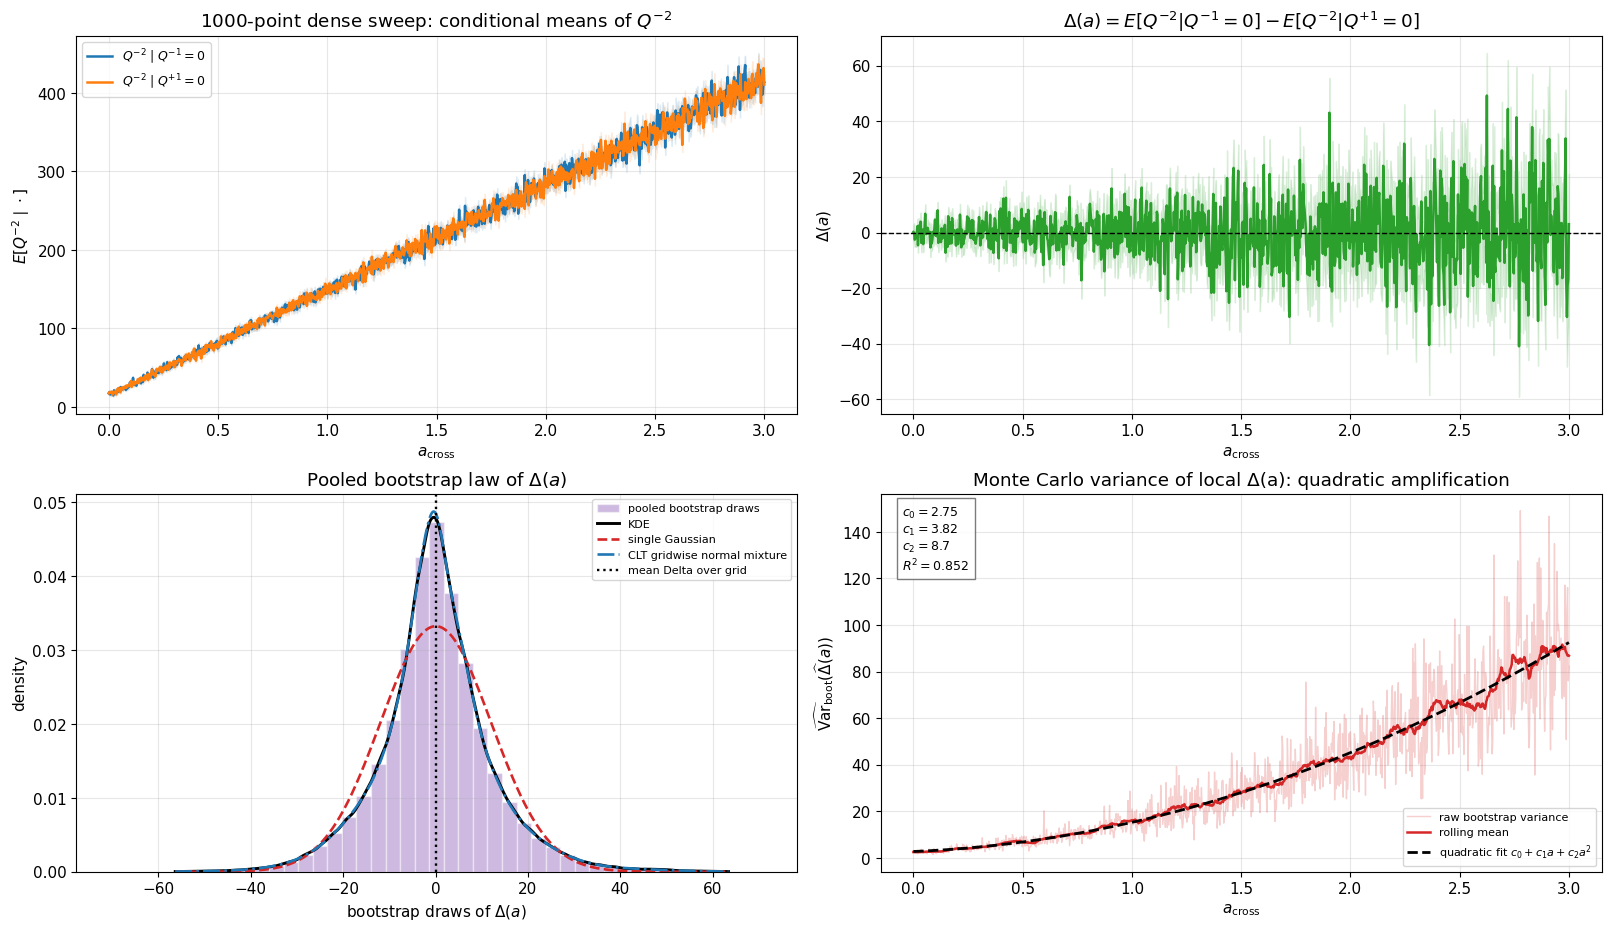


**Interprétation de la sensibilité dense.** Le balayage utilise 1000 valeurs uniformes de $a_{cross}$ entre 0.0 et 3.0.
Sur cette grille, la moyenne empirique de $\Delta(a)$ vaut 0.03, sa variance vaut 109.82, et les quantiles 5/50/95 % sont [-17.05, -0.21, 17.58].
Au point $a=0$, on obtient $\Delta(0)=0.20$; au point le plus proche de $a=3.0$, $\Delta(3.0)=3.01$.
La proportion de points avec $\Delta(a)>0$ est 48.7%, et la proportion dont l'IC bootstrap exclut zéro est 28.4%.
La distribution pooled bootstrap de $\Delta(a)$ est mélange empirique de lois approximativement normales. Pour un $a$ fixé, le bootstrap d'une différence de moyennes est approximativement normal par effet limite central; en mélangeant 1000 valeurs de $a$, on obtient donc naturellement un mélange de normales. Ici la skewness vaut 0.22, l'excès de kurtosis vaut 1.96; la comparaison des distances $L^1$ à la KDE indique que le mélange normal CLT par valeur de a décrit mieux la densité empirique.
Pour la variance bootstrap locale, le coefficient quadratique ajusté vaut $c_2=8.7$ avec $R^2=0.852$. On l'interprète comme un proxy empirique de l'amplification stochastique quadratique, pas comme une estimation exacte de $\operatorname{Var}(I_T)$ dans le modèle couplé complet.


In [10]:
def normal_pdf_1d(grid, mean, std):
    """Normal density evaluated on a one-dimensional grid."""
    grid = np.asarray(grid, dtype=float)
    if not np.isfinite(std) or std <= 0:
        return np.full_like(grid, np.nan, dtype=float)
    z = (grid - mean) / std
    return np.exp(-0.5 * z * z) / (std * np.sqrt(2.0 * np.pi))


def gaussian_kde_1d(values, grid, bandwidth=None, chunk_size=5_000):
    """Simple Gaussian KDE without scipy, using Silverman's bandwidth by default."""
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    grid = np.asarray(grid, dtype=float)
    if len(x) == 0:
        return np.full_like(grid, np.nan, dtype=float), np.nan
    if bandwidth is None:
        std = np.std(x, ddof=1) if len(x) > 1 else 1.0
        iqr = np.subtract(*np.quantile(x, [0.75, 0.25])) if len(x) > 1 else std
        sigma = min(std, iqr / 1.349) if iqr > 0 else std
        bandwidth = 0.9 * sigma * len(x) ** (-1.0 / 5.0)
    if not np.isfinite(bandwidth) or bandwidth <= 0:
        fallback_std = np.std(x, ddof=1) if len(x) > 1 else 1.0
        bandwidth = max(fallback_std, 1.0) * len(x) ** (-1.0 / 5.0)
    density = np.zeros_like(grid, dtype=float)
    normalizer = bandwidth * np.sqrt(2.0 * np.pi) * len(x)
    for start in range(0, len(x), chunk_size):
        chunk = x[start:start + chunk_size]
        z = (grid[:, None] - chunk[None, :]) / bandwidth
        density += np.exp(-0.5 * z * z).sum(axis=1) / normalizer
    return density, float(bandwidth)


def gridwise_normal_mixture_pdf(grid, means, variances, weights=None):
    """CLT gridwise normal mixture for local bootstrap laws of Delta(a)."""
    grid = np.asarray(grid, dtype=float)
    means = np.asarray(means, dtype=float)
    variances = np.asarray(variances, dtype=float)
    stds = np.sqrt(np.maximum(variances, 0.0))
    if weights is None:
        weights = np.ones_like(means, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(means) & np.isfinite(stds) & (stds > 0) & np.isfinite(weights) & (weights > 0)
    if not np.any(mask):
        return np.full_like(grid, np.nan, dtype=float)
    means = means[mask]
    stds = stds[mask]
    weights = weights[mask] / np.sum(weights[mask])
    density = np.zeros_like(grid, dtype=float)
    for mean, std, weight in zip(means, stds, weights):
        density += weight * normal_pdf_1d(grid, mean, std)
    return density


def quadratic_fit(x, y):
    """Least-squares fit y = c0 + c1 x + c2 x^2 with R^2 diagnostics."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        raise ValueError('Need at least three finite grid points for a quadratic variance fit.')
    X = np.column_stack([np.ones_like(x), x, x * x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ coef
    ss_res = float(np.sum((y - fitted) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return coef, fitted, r2, x, y


def rolling_mean(values, window):
    """Centered rolling mean used only as a visual smoother."""
    series = pd.Series(np.asarray(values, dtype=float))
    window = int(max(3, window))
    if window % 2 == 0:
        window += 1
    return series.rolling(window=window, center=True, min_periods=max(2, window // 3)).mean().to_numpy()


required_dense_vars = ['sensitivity_table', 'delta_table', 'delta_bootstrap_distribution']
missing_dense_vars = [name for name in required_dense_vars if name not in globals()]

if missing_dense_vars:
    display_fr(
        r'**Diagnostic.** Les variables suivantes sont absentes et empêchent le fitting dense de $\Delta(a)$ : '
        + ', '.join(missing_dense_vars)
        + '. Exécuter d abord la cellule du balayage dense 1.2.5.0(k).'
    )
else:
    needed_delta_columns = {'a_cross', 'delta_mean', 'delta_bootstrap_variance'}
    needed_draw_columns = {'a_cross', 'delta_bootstrap_draw'}
    missing_delta_columns = needed_delta_columns - set(delta_table.columns)
    missing_draw_columns = needed_draw_columns - set(delta_bootstrap_distribution.columns)
    if missing_delta_columns or missing_draw_columns:
        display_fr(
            '**Diagnostic.** Colonnes manquantes pour le fitting dense : '
            f'delta_table={sorted(missing_delta_columns)}, '
            f'delta_bootstrap_distribution={sorted(missing_draw_columns)}.'
        )
    else:
        delta_fit_data = delta_table[['a_cross', 'delta_mean', 'delta_bootstrap_variance']].copy()
        delta_fit_data['delta_bootstrap_variance'] = pd.to_numeric(delta_fit_data['delta_bootstrap_variance'], errors='coerce')
        draw_counts = (
            delta_bootstrap_distribution
            .dropna(subset=['a_cross', 'delta_bootstrap_draw'])
            .groupby('a_cross', as_index=False)['delta_bootstrap_draw']
            .size()
            .rename(columns={'size': 'n_bootstrap_draws_at_a'})
        )
        delta_fit_data = delta_fit_data.merge(draw_counts, on='a_cross', how='left')
        delta_fit_data['n_bootstrap_draws_at_a'] = delta_fit_data['n_bootstrap_draws_at_a'].fillna(0).astype(int)

        bad_variance = ~np.isfinite(delta_fit_data['delta_bootstrap_variance']) | (delta_fit_data['delta_bootstrap_variance'] < 0)
        if bad_variance.any():
            warnings.warn(
                f'Dropping {int(bad_variance.sum())} grid points with NaN or negative bootstrap variance.',
                RuntimeWarning,
            )
        variance_fit_data = delta_fit_data.loc[~bad_variance & (delta_fit_data['n_bootstrap_draws_at_a'] > 1)].copy()
        if len(variance_fit_data) < 3:
            raise ValueError('Not enough finite nonnegative bootstrap variances for quadratic fitting.')

        pooled_delta = delta_bootstrap_distribution['delta_bootstrap_draw'].dropna().to_numpy(dtype=float)
        if len(pooled_delta) < 2:
            raise ValueError('Not enough pooled bootstrap draws for density fitting.')

        pooled_mean = float(np.mean(pooled_delta))
        pooled_std = float(np.std(pooled_delta, ddof=1))
        centered = pooled_delta - pooled_mean
        pooled_skew = float(np.mean(centered ** 3) / pooled_std ** 3) if pooled_std > 0 else np.nan
        pooled_excess_kurtosis = float(np.mean(centered ** 4) / pooled_std ** 4 - 3.0) if pooled_std > 0 else np.nan

        x_low, x_high = np.quantile(pooled_delta, [0.001, 0.999])
        pad = 0.12 * max(x_high - x_low, 1.0)
        density_grid = np.linspace(x_low - pad, x_high + pad, 600)
        kde_density, kde_bandwidth = gaussian_kde_1d(pooled_delta, density_grid)
        normal_density = normal_pdf_1d(density_grid, pooled_mean, pooled_std)
        mixture_density = gridwise_normal_mixture_pdf(
            density_grid,
            variance_fit_data['delta_mean'].to_numpy(dtype=float),
            variance_fit_data['delta_bootstrap_variance'].to_numpy(dtype=float),
            weights=variance_fit_data['n_bootstrap_draws_at_a'].to_numpy(dtype=float),
        )

        dx = density_grid[1] - density_grid[0]
        l1_normal = float(np.nansum(np.abs(kde_density - normal_density)) * dx)
        l1_mixture = float(np.nansum(np.abs(kde_density - mixture_density)) * dx)
        kde_mode = float(density_grid[np.nanargmax(kde_density)])

        pooled_density_diagnostics = pd.DataFrame([{
            'n_bootstrap_draws': len(pooled_delta),
            'n_grid_points': int(len(variance_fit_data)),
            'mean': pooled_mean,
            'std': pooled_std,
            'variance': pooled_std ** 2,
            'skewness': pooled_skew,
            'excess_kurtosis': pooled_excess_kurtosis,
            'kde_bandwidth': kde_bandwidth,
            'kde_mode': kde_mode,
            'L1_KDE_vs_single_normal': l1_normal,
            'L1_KDE_vs_gridwise_normal_mixture': l1_mixture,
        }])

        delta_fit_comparison = pd.DataFrame([
            {'fit': 'Single Gaussian', 'L1_distance_to_KDE': l1_normal},
            {'fit': 'CLT gridwise normal mixture', 'L1_distance_to_KDE': l1_mixture},
        ])

        coef, fitted_variance, quadratic_r2, fit_a, fit_variance = quadratic_fit(
            variance_fit_data['a_cross'].to_numpy(dtype=float),
            variance_fit_data['delta_bootstrap_variance'].to_numpy(dtype=float),
        )
        c0, c1, c2 = [float(v) for v in coef]
        if c2 < 0:
            warnings.warn(
                'Quadratic coefficient c2 is negative; this contradicts the expected convex amplification diagnostic.',
                RuntimeWarning,
            )
        quadratic_variance_fit_table = pd.DataFrame([{
            'c0': c0,
            'c1': c1,
            'c2': c2,
            'R2': float(quadratic_r2),
            'n_grid_points': int(len(fit_a)),
            'variance_min': float(np.min(fit_variance)),
            'variance_max': float(np.max(fit_variance)),
            'rolling_window': int(max(21, len(fit_a) // 40) if len(fit_a) >= 40 else 5),
        }])

        variance_fit_data['quadratic_fit'] = fitted_variance
        variance_fit_data['smoothed_variance'] = rolling_mean(
            variance_fit_data['delta_bootstrap_variance'],
            quadratic_variance_fit_table.loc[0, 'rolling_window'],
        )

        display(format_metric_table(pooled_density_diagnostics, 4))
        display(format_metric_table(delta_fit_comparison, 4))
        display(format_metric_table(quadratic_variance_fit_table, 4))

        def plot_delta_sweep_four_panel(title_prefix='1000-point dense sweep'):
            fig, axes = plt.subplots(2, 2, figsize=(16, 9.2), layout='constrained')

            for side, color, label in [
                ('same', 'tab:blue', r'$Q^{-2}\mid Q^{-1}=0$'),
                ('opposite', 'tab:orange', r'$Q^{-2}\mid Q^{+1}=0$'),
            ]:
                part = sensitivity_table[sensitivity_table['side'] == side].sort_values('a_cross')
                axes[0, 0].plot(part['a_cross'], part['mean_Q_minus_2'], linewidth=1.8, label=label, color=color)
                axes[0, 0].fill_between(part['a_cross'], part['mean_ci_low'], part['mean_ci_high'], alpha=0.12, color=color)
            axes[0, 0].set_xlabel(r'$a_{\mathrm{cross}}$')
            axes[0, 0].set_ylabel(r'$E[Q^{-2}\mid \cdot]$')
            axes[0, 0].set_title(f'{title_prefix}: conditional means of $Q^{{-2}}$')
            axes[0, 0].legend(fontsize=9)

            axes[0, 1].plot(delta_table['a_cross'], delta_table['delta_mean'], color='tab:green', linewidth=1.8)
            axes[0, 1].fill_between(delta_table['a_cross'], delta_table['ci_low'], delta_table['ci_high'], color='tab:green', alpha=0.16)
            axes[0, 1].axhline(0.0, color='black', linewidth=1.0, linestyle='--')
            axes[0, 1].set_xlabel(r'$a_{\mathrm{cross}}$')
            axes[0, 1].set_ylabel(r'$\Delta(a)$')
            axes[0, 1].set_title(r'$\Delta(a)=E[Q^{-2}|Q^{-1}=0]-E[Q^{-2}|Q^{+1}=0]$')

            axes[1, 0].hist(pooled_delta, bins=45, density=True, alpha=0.45, color='tab:purple', edgecolor='white', label='pooled bootstrap draws')
            axes[1, 0].plot(density_grid, kde_density, color='black', linewidth=2.1, label='KDE')
            axes[1, 0].plot(density_grid, normal_density, color='tab:red', linestyle='--', linewidth=1.9, label='single Gaussian')
            axes[1, 0].plot(density_grid, mixture_density, color='tab:blue', linestyle='-.', linewidth=1.9, label='CLT gridwise normal mixture')
            axes[1, 0].axvline(delta_table['delta_mean'].mean(), color='black', linestyle=':', linewidth=1.7, label='mean Delta over grid')
            axes[1, 0].set_xlabel(r'bootstrap draws of $\Delta(a)$')
            axes[1, 0].set_ylabel('density')
            axes[1, 0].set_title(r'Pooled bootstrap law of $\Delta(a)$')
            axes[1, 0].legend(fontsize=8)

            axes[1, 1].plot(
                variance_fit_data['a_cross'],
                variance_fit_data['delta_bootstrap_variance'],
                color='tab:red', alpha=0.22, linewidth=1.0, label='raw bootstrap variance',
            )
            axes[1, 1].plot(
                variance_fit_data['a_cross'],
                variance_fit_data['smoothed_variance'],
                color='tab:red', linewidth=1.8, label='rolling mean',
            )
            axes[1, 1].plot(
                variance_fit_data['a_cross'],
                variance_fit_data['quadratic_fit'],
                color='black', linestyle='--', linewidth=2.0, label=r'quadratic fit $c_0+c_1a+c_2a^2$',
            )
            axes[1, 1].set_xlabel(r'$a_{\mathrm{cross}}$')
            axes[1, 1].set_ylabel(r'$\widehat{\mathrm{Var}}_{\mathrm{boot}}(\widehat{\Delta}(a))$')
            axes[1, 1].set_title('Monte Carlo variance of local Δ(a): quadratic amplification')
            axes[1, 1].legend(fontsize=8)
            text = (
                f'$c_0={c0:.3g}$\n'
                f'$c_1={c1:.3g}$\n'
                f'$c_2={c2:.3g}$\n'
                f'$R^2={quadratic_r2:.3f}$'
            )
            axes[1, 1].text(
                0.03, 0.97, text,
                transform=axes[1, 1].transAxes,
                va='top', ha='left', fontsize=9,
                bbox={'facecolor': 'white', 'edgecolor': '0.4', 'alpha': 0.86},
            )
            plt.show()

        plot_delta_sweep_four_panel()

        summary = delta_distribution_summary.iloc[0]
        a0 = delta_table.iloc[(delta_table['a_cross'] - 0.0).abs().argmin()]
        last = delta_table.iloc[(delta_table['a_cross'] - DENSE_A_MAX).abs().argmin()]
        positive_share = float((delta_table['delta_mean'] > 0).mean())
        significant_share = float(delta_table['significant'].mean())
        distribution_label = 'mélange empirique de lois approximativement normales'
        if abs(pooled_skew) < 0.25 and abs(pooled_excess_kurtosis) < 0.5 and l1_normal <= l1_mixture * 1.1:
            distribution_label = 'proche d une loi normale unique'
        better_fit = 'le mélange normal CLT par valeur de a' if l1_mixture < l1_normal else 'la normale unique ajustée'

        display_fr(
            fr"""
**Interprétation de la sensibilité dense.** Le balayage utilise {int(summary['n_a_grid'])} valeurs uniformes de $a_{{cross}}$ entre {summary['a_min']:.1f} et {summary['a_max']:.1f}.
Sur cette grille, la moyenne empirique de $\Delta(a)$ vaut {summary['mean_delta_over_grid']:.2f}, sa variance vaut {summary['variance_delta_over_grid']:.2f}, et les quantiles 5/50/95 % sont [{summary['q05_delta_over_grid']:.2f}, {summary['median_delta_over_grid']:.2f}, {summary['q95_delta_over_grid']:.2f}].
Au point $a=0$, on obtient $\Delta(0)={a0['delta_mean']:.2f}$; au point le plus proche de $a={DENSE_A_MAX:.1f}$, $\Delta({DENSE_A_MAX:.1f})={last['delta_mean']:.2f}$.
La proportion de points avec $\Delta(a)>0$ est {positive_share:.1%}, et la proportion dont l'IC bootstrap exclut zéro est {significant_share:.1%}.
La distribution pooled bootstrap de $\Delta(a)$ est {distribution_label}. Pour un $a$ fixé, le bootstrap d'une différence de moyennes est approximativement normal par effet limite central; en mélangeant {int(summary['n_a_grid'])} valeurs de $a$, on obtient donc naturellement un mélange de normales. Ici la skewness vaut {pooled_skew:.2f}, l'excès de kurtosis vaut {pooled_excess_kurtosis:.2f}; la comparaison des distances $L^1$ à la KDE indique que {better_fit} décrit mieux la densité empirique.
Pour la variance bootstrap locale, le coefficient quadratique ajusté vaut $c_2={c2:.3g}$ avec $R^2={quadratic_r2:.3f}$. On l'interprète comme un proxy empirique de l'amplification stochastique quadratique, pas comme une estimation exacte de $\operatorname{{Var}}(I_T)$ dans le modèle couplé complet.
"""
        )

### Distribution empirique directe de $\Delta(a)$ sur la grille de $a_{cross}$

Le graphique précédent sur les bootstrap draws décrit l'incertitude Monte Carlo de l'estimateur. Ici on trace une autre quantité : la distribution empirique des valeurs

$$
\{\widehat{\Delta}(a_j): j=1,\ldots,J\}
$$

lorsque $a_{cross}$ parcourt uniformément la grille dense. Cette distribution ne demande aucune nouvelle simulation : elle réutilise uniquement `delta_table['delta_mean']`, déjà calculé dans `1.2.5.0(k)`. Elle doit être lue comme la loi empirique de la fonction de sensibilité évaluée sur une grille uniforme, pas comme une loi conditionnelle du carnet d'ordres.

,object,n_grid_points,mean,std,variance,q05,median,q95,skewness,excess_kurtosis,kde_bandwidth,kde_mode,L1_KDE_vs_single_normal
0,Delta(a) over a_cross grid,1000,0.0257,10.4795,109.8208,-17.0513,-0.2057,17.5766,0.2747,2.0007,1.7922,-0.5474,0.2231


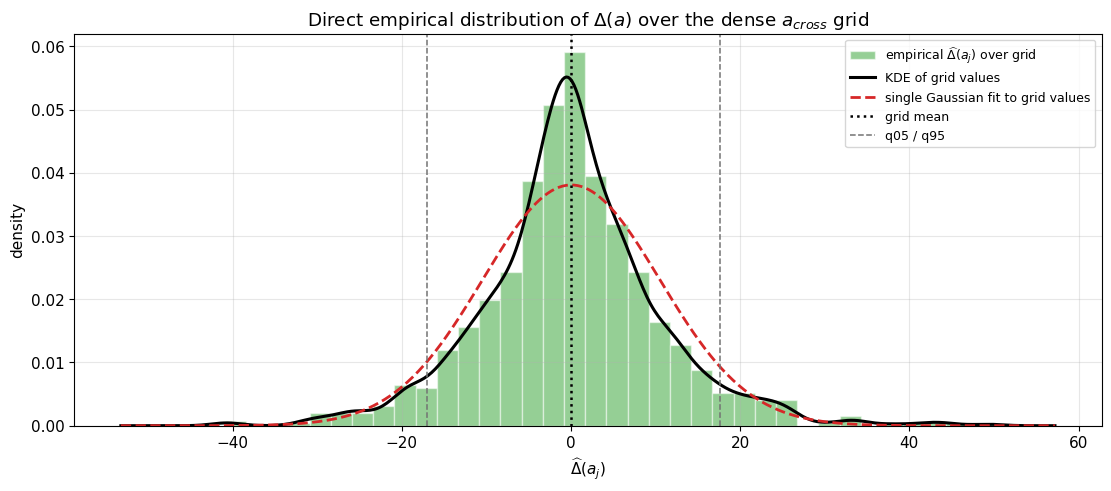


**Interprétation.** Cette figure montre directement la distribution empirique des 1000 valeurs $\widehat{\Delta}(a_j)$ sur la grille uniforme de $a_{cross}$.
La moyenne vaut 0.03, la médiane vaut -0.21, et l'intervalle empirique 5/95 % est [-17.05, 17.58].
La skewness est 0.27 et l'excès de kurtosis est 2.00; la normale unique ne capture pas entièrement la forme empirique; la KDE est plus informative.
Cette distribution répond à une question différente du pooled bootstrap : ici on regarde la variabilité de la fonction $a\mapsto\Delta(a)$ sur la grille, alors que le pooled bootstrap mesure l'incertitude Monte Carlo autour de ces valeurs.


In [11]:
if 'delta_table' not in globals():
    display_fr(
        "**Diagnostic.** `delta_table` est absent. Exécuter d'abord le balayage dense `1.2.5.0(k)`; "
        "cette cellule ne relance aucune simulation MCRS."
    )
else:
    delta_grid_values = delta_table['delta_mean'].dropna().to_numpy(dtype=float)
    if len(delta_grid_values) < 2:
        display_fr('**Diagnostic.** Pas assez de valeurs finies de $\\Delta(a)$ pour estimer une densité.')
    else:
        delta_grid_mean = float(np.mean(delta_grid_values))
        delta_grid_std = float(np.std(delta_grid_values, ddof=1))
        delta_grid_variance = float(np.var(delta_grid_values, ddof=1))
        delta_grid_centered = delta_grid_values - delta_grid_mean
        delta_grid_skewness = float(np.mean(delta_grid_centered ** 3) / delta_grid_std ** 3) if delta_grid_std > 0 else np.nan
        delta_grid_excess_kurtosis = float(np.mean(delta_grid_centered ** 4) / delta_grid_std ** 4 - 3.0) if delta_grid_std > 0 else np.nan
        delta_grid_q05, delta_grid_median, delta_grid_q95 = np.quantile(delta_grid_values, [0.05, 0.50, 0.95])

        grid_low, grid_high = np.quantile(delta_grid_values, [0.001, 0.999])
        grid_pad = 0.15 * max(grid_high - grid_low, 1.0)
        delta_empirical_density_grid = np.linspace(grid_low - grid_pad, grid_high + grid_pad, 500)
        delta_empirical_kde, delta_empirical_kde_bandwidth = gaussian_kde_1d(
            delta_grid_values,
            delta_empirical_density_grid,
        )
        delta_empirical_normal_density = normal_pdf_1d(
            delta_empirical_density_grid,
            delta_grid_mean,
            delta_grid_std,
        )
        dx_delta_grid = delta_empirical_density_grid[1] - delta_empirical_density_grid[0]
        delta_empirical_l1_normal = float(
            np.nansum(np.abs(delta_empirical_kde - delta_empirical_normal_density)) * dx_delta_grid
        )
        delta_empirical_kde_mode = float(delta_empirical_density_grid[np.nanargmax(delta_empirical_kde)])

        delta_empirical_distribution_diagnostics = pd.DataFrame([{
            'object': 'Delta(a) over a_cross grid',
            'n_grid_points': int(len(delta_grid_values)),
            'mean': delta_grid_mean,
            'std': delta_grid_std,
            'variance': delta_grid_variance,
            'q05': float(delta_grid_q05),
            'median': float(delta_grid_median),
            'q95': float(delta_grid_q95),
            'skewness': delta_grid_skewness,
            'excess_kurtosis': delta_grid_excess_kurtosis,
            'kde_bandwidth': delta_empirical_kde_bandwidth,
            'kde_mode': delta_empirical_kde_mode,
            'L1_KDE_vs_single_normal': delta_empirical_l1_normal,
        }])
        display(format_metric_table(delta_empirical_distribution_diagnostics, 4))

        fig, ax = plt.subplots(figsize=(11, 4.8), layout='constrained')
        ax.hist(
            delta_grid_values,
            bins=36,
            density=True,
            alpha=0.50,
            color='tab:green',
            edgecolor='white',
            label=r'empirical $\widehat{\Delta}(a_j)$ over grid',
        )
        ax.plot(
            delta_empirical_density_grid,
            delta_empirical_kde,
            color='black',
            linewidth=2.2,
            label='KDE of grid values',
        )
        ax.plot(
            delta_empirical_density_grid,
            delta_empirical_normal_density,
            color='tab:red',
            linestyle='--',
            linewidth=2.0,
            label='single Gaussian fit to grid values',
        )
        ax.axvline(delta_grid_mean, color='black', linestyle=':', linewidth=1.8, label='grid mean')
        ax.axvline(delta_grid_q05, color='0.45', linestyle='--', linewidth=1.1, label='q05 / q95')
        ax.axvline(delta_grid_q95, color='0.45', linestyle='--', linewidth=1.1)
        ax.set_title(r'Direct empirical distribution of $\Delta(a)$ over the dense $a_{cross}$ grid')
        ax.set_xlabel(r'$\widehat{\Delta}(a_j)$')
        ax.set_ylabel('density')
        ax.legend(fontsize=9)
        plt.show()

        normal_fit_comment = (
            'la normale unique donne une approximation raisonnable de premier ordre'
            if delta_empirical_l1_normal < 0.15
            else 'la normale unique ne capture pas entièrement la forme empirique; la KDE est plus informative'
        )
        display_fr(
            fr"""
**Interprétation.** Cette figure montre directement la distribution empirique des {len(delta_grid_values)} valeurs $\widehat{{\Delta}}(a_j)$ sur la grille uniforme de $a_{{cross}}$.
La moyenne vaut {delta_grid_mean:.2f}, la médiane vaut {delta_grid_median:.2f}, et l'intervalle empirique 5/95 % est [{delta_grid_q05:.2f}, {delta_grid_q95:.2f}].
La skewness est {delta_grid_skewness:.2f} et l'excès de kurtosis est {delta_grid_excess_kurtosis:.2f}; {normal_fit_comment}.
Cette distribution répond à une question différente du pooled bootstrap : ici on regarde la variabilité de la fonction $a\mapsto\Delta(a)$ sur la grille, alors que le pooled bootstrap mesure l'incertitude Monte Carlo autour de ces valeurs.
"""
        )

Le profil croissant de la variance bootstrap n'est pas interprété comme un simple artefact numérique. Lorsque $a_{\mathrm{cross}}$ augmente, l'intensité de réapprovisionnement de la deuxième limite devient plus sensible aux retraits de la première limite. Par analogie avec la formule de variance totale,

$$
\mathrm{Var}(N_T^{2,+}) = \mu T + a\mathbb E[I_T] + a^2\mathrm{Var}(I_T),
$$

la variance contient un terme quadratique en $a_{\mathrm{cross}}$. L'ajustement quadratique fournit donc un diagnostic empirique de cet effet d'amplification stochastique. Le coefficient $c_2$ doit cependant être lu comme un proxy du terme quadratique : il n'est pas une estimation exacte de $\mathrm{Var}(I_T)$, car la quantité tracée est la variance bootstrap de l'estimateur $\Delta(a)$, c'est-à-dire une différence de deux moyennes conditionnelles MCRS.

### 1.2.5.0(o) Synthèse de la méthode MCRS

Les conclusions attendues sont vérifiées par les diagnostics précédents :

1. Lorsque $a_{cross}=0$, les distributions same-side et opposite-side doivent être proches; un écart important serait un signal de bruit Monte Carlo ou d'asymétrie non prévue.
2. Lorsque $a_{cross}>0$, le mécanisme $Q^{-1}\to Q^{-2}$ doit déplacer $Q^{-2}\mid Q^{-1}=0$ vers la droite si l'effet domine le bruit.
3. Le burn-in stabilise la loi conditionnelle de $S$ en réduisant l'effet du choix arbitraire $H=G=0$ au départ.
4. MCRS peut réduire le coût CPU par échantillon conditionnel, mais son efficacité statistique dépend de la diversité des checkpoints frontière.
5. Si la probabilité estimée vaut 1, l'IC Bernoulli est dégénéré; il faut comparer les incertitudes bootstrap des statistiques conditionnelles de $Q^{-2}$.

La dynamique stochastique de `hawkes_4q.py` n'a pas été modifiée : les changements portent sur l'estimateur, les diagnostics, les graphiques et l'interprétation.

## Résultats directs pour les questions 1.2.5

La partie `1.2.5.0` documente la construction de MCRS : choix des checkpoints, loi conditionnelle de $S$, redémarrage local et diagnostics. Les deux sections suivantes répondent **point par point** aux questions du sujet.

La convention utilisée dans le code est :

$$
(Q^{+1},Q^{-1},Q^{+2},Q^{-2}) \equiv \texttt{state}[0:4].
$$

L'indice positif correspond au côté ask et l'indice négatif au côté bid. Les estimations ci-dessous utilisent MCRS comme estimateur conditionnel; Ogata thinning reste le simulateur de trajectoire sous-jacent.

In [12]:
def success_queue(result, position):
    """Queue value at the local successful depletion time."""
    success = np.asarray(result.observables['success'], dtype=bool)
    final_queues = np.asarray(result.observables['final_queues'], dtype=float)
    return final_queues[success, position]


def conditional_queue_summary(values, seed):
    values = np.asarray(values, dtype=float)
    ci = bootstrap_mean_ci(values, n_bootstrap=BOOTSTRAP_REPS, rng=seed) if len(values) else (np.nan, np.nan)
    return {
        'n_samples': int(len(values)),
        'mean': float(np.mean(values)) if len(values) else np.nan,
        'std': float(np.std(values, ddof=1)) if len(values) > 1 else np.nan,
        'q05': float(np.quantile(values, 0.05)) if len(values) else np.nan,
        'median': float(np.quantile(values, 0.50)) if len(values) else np.nan,
        'q95': float(np.quantile(values, 0.95)) if len(values) else np.nan,
        'bootstrap_ci_low': ci[0],
        'bootstrap_ci_high': ci[1],
        'bootstrap_ci_width': ci[1] - ci[0] if np.isfinite(ci[0]) and np.isfinite(ci[1]) else np.nan,
    }


def course_result_row(bundle, variable, condition, position, seed):
    result = bundle['result']
    values = success_queue(result, position)
    row = {
        'variable': variable,
        'condition': condition,
        'a_cross': bundle['params'].a_cross,
        **conditional_queue_summary(values, seed),
        'success_probability': result.diagnostics['success_probability'],
        'recovery_probability': result.diagnostics['recovery_probability'],
        'timeout_probability': result.diagnostics['timeout_probability'],
        'checkpoint_usage_ess': result.diagnostics.get('checkpoint_usage_ess', result.diagnostics.get('checkpoint_usage_effective_sample_size', np.nan)),
        'cpu_seconds': total_cpu_seconds(bundle),
        'acceptance_candidate_ratio': result.diagnostics['acceptance_candidate_ratio'],
    }
    return row, values


def delta_ci_from_values(left, right, seed):
    ci = bootstrap_difference_ci(left, right, n_bootstrap=BOOTSTRAP_REPS, rng=seed)
    delta = float(np.mean(left) - np.mean(right)) if len(left) and len(right) else np.nan
    return delta, ci[0], ci[1]

COURSE_N_BOUNDARY_PATHS = N_BOUNDARY_PATHS
COURSE_N_RESTARTS = N_RESTARTS

## 1.2.5.1 — Deuxièmes limites constantes

Dans cette première question, les intensités des deuxièmes limites sont constantes. Dans le code cela correspond à :

$$
a_{cross}=0.
$$

L'objet central du notebook est la deuxième limite bid $Q^{-2}$. On estime donc directement :

1. la loi de $Q^{-2}$ sachant que $Q^{-1}=0$ ;
2. la loi de $Q^{-2}$ sachant que $Q^{+1}=0$.

La première loi est la loi **same-side** : la première limite bid $Q^{-1}$ disparaît et l'on observe la deuxième limite bid $Q^{-2}$. La seconde est la loi **opposite-side** : la première limite ask $Q^{+1}$ disparaît et l'on observe quand même $Q^{-2}$.

Lorsque $a_{cross}=0$, le modèle est symétrique entre ask et bid. On vérifie donc aussi les lois miroir de $Q^{+2}$, uniquement comme contrôle de symétrie, mais la réponse principale reste formulée en termes de $Q^{-2}$.

In [13]:
params_constant_second = make_params(a_cross=0.0)
const_ask_depletion = run_mcrs_side(
    params_constant_second,
    queue_index=1,
    seed=SEED + 12_501,
    n_boundary_paths=COURSE_N_BOUNDARY_PATHS,
    n_restarts=COURSE_N_RESTARTS,
)
const_bid_depletion = run_mcrs_side(
    params_constant_second,
    queue_index=-1,
    seed=SEED + 12_502,
    n_boundary_paths=COURSE_N_BOUNDARY_PATHS,
    n_restarts=COURSE_N_RESTARTS,
)

constant_rows = []
constant_values = {}
for key, bundle, variable, condition, position, seed in [
    ('Q-2 | Q-1=0', const_bid_depletion, 'Q^{-2}', 'Q^{-1}=0', 3, SEED + 12_601),
    ('Q-2 | Q+1=0', const_ask_depletion, 'Q^{-2}', 'Q^{+1}=0', 3, SEED + 12_602),
    ('mirror Q+2 | Q+1=0', const_ask_depletion, 'Q^{+2}', 'Q^{+1}=0', 2, SEED + 12_603),
    ('mirror Q+2 | Q-1=0', const_bid_depletion, 'Q^{+2}', 'Q^{-1}=0', 2, SEED + 12_604),
]:
    row, values = course_result_row(bundle, variable, condition, position, seed)
    constant_rows.append(row)
    constant_values[key] = values

constant_second_limit_table = pd.DataFrame(constant_rows)
display(format_metric_table(constant_second_limit_table, 3))

same_sym_delta, same_sym_low, same_sym_high = delta_ci_from_values(
    constant_values['Q-2 | Q-1=0'],
    constant_values['mirror Q+2 | Q+1=0'],
    SEED + 12_701,
)
opp_sym_delta, opp_sym_low, opp_sym_high = delta_ci_from_values(
    constant_values['Q-2 | Q+1=0'],
    constant_values['mirror Q+2 | Q-1=0'],
    SEED + 12_702,
)

symmetry_check_table = pd.DataFrame([
    {
        'comparison': 'same-side mirror: Q-2|Q-1=0 minus Q+2|Q+1=0',
        'delta_mean': same_sym_delta,
        'bootstrap_ci_low': same_sym_low,
        'bootstrap_ci_high': same_sym_high,
        'ci_contains_zero': same_sym_low <= 0 <= same_sym_high,
    },
    {
        'comparison': 'opposite-side mirror: Q-2|Q+1=0 minus Q+2|Q-1=0',
        'delta_mean': opp_sym_delta,
        'bootstrap_ci_low': opp_sym_low,
        'bootstrap_ci_high': opp_sym_high,
        'ci_contains_zero': opp_sym_low <= 0 <= opp_sym_high,
    },
])
display(format_metric_table(symmetry_check_table, 3))

,variable,condition,a_cross,n_samples,mean,std,q05,median,q95,bootstrap_ci_low,bootstrap_ci_high,bootstrap_ci_width,success_probability,recovery_probability,timeout_probability,checkpoint_usage_ess,cpu_seconds,acceptance_candidate_ratio
0,Q^{-2},Q^{-1}=0,0.0,859,15.644,7.645,3.0,16.0,29.0,15.163,16.141,0.978,0.859,0.141,0.0,225.530,1.676,0.978
1,Q^{-2},Q^{+1}=0,0.0,887,15.434,7.449,2.0,16.0,28.0,14.958,15.903,0.945,0.887,0.113,0.0,232.126,1.749,0.981
2,Q^{+2},Q^{+1}=0,0.0,887,16.200,7.918,4.0,16.0,31.0,15.700,16.704,1.003,0.887,0.113,0.0,232.126,1.749,0.981
3,Q^{+2},Q^{-1}=0,0.0,859,15.070,7.699,3.0,14.0,28.1,14.546,15.572,1.026,0.859,0.141,0.0,225.530,1.676,0.978


,comparison,delta_mean,bootstrap_ci_low,bootstrap_ci_high,ci_contains_zero
0,same-side mirror: Q-2|Q-1=0 minus Q+2|Q+1=0,-0.556,-1.312,0.160,True
1,opposite-side mirror: Q-2|Q+1=0 minus Q+2|Q-1=0,0.364,-0.368,1.037,True


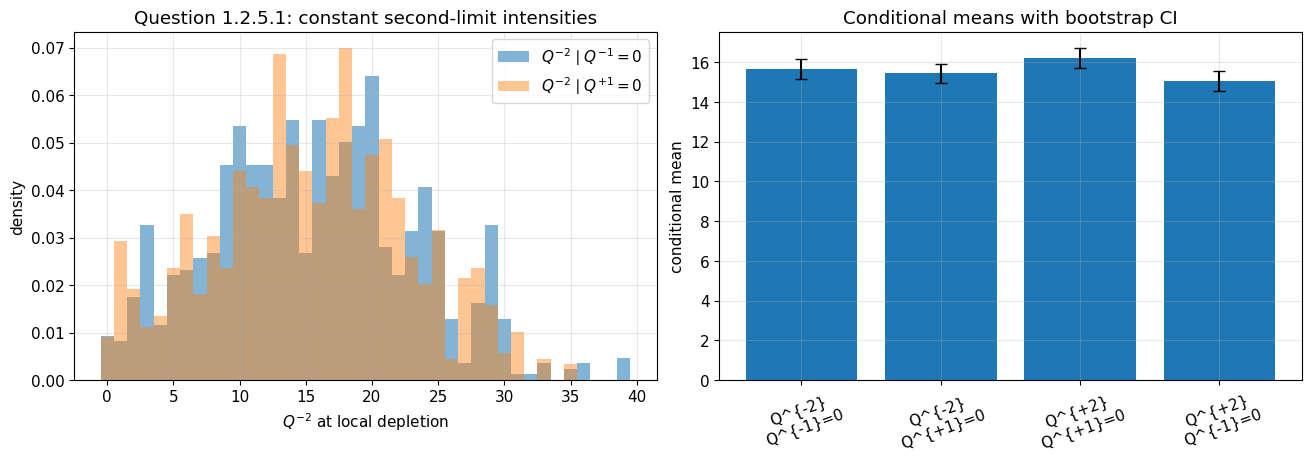

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')

bins = np.arange(
    min(constant_values['Q-2 | Q-1=0'].min(), constant_values['Q-2 | Q+1=0'].min()) - 0.5,
    max(constant_values['Q-2 | Q-1=0'].max(), constant_values['Q-2 | Q+1=0'].max()) + 1.5,
    1,
)
axes[0].hist(constant_values['Q-2 | Q-1=0'], bins=bins, density=True, alpha=0.55, label=r'$Q^{-2}\mid Q^{-1}=0$')
axes[0].hist(constant_values['Q-2 | Q+1=0'], bins=bins, density=True, alpha=0.45, label=r'$Q^{-2}\mid Q^{+1}=0$')
axes[0].set_title(r'Question 1.2.5.1: constant second-limit intensities')
axes[0].set_xlabel(r'$Q^{-2}$ at local depletion')
axes[0].set_ylabel('density')
axes[0].legend()

plot_data = constant_second_limit_table.copy()
plot_data['label'] = plot_data['variable'].astype(str).str.cat(plot_data['condition'].astype(str), sep=chr(10))
axes[1].bar(plot_data['label'], plot_data['mean'], yerr=[
    plot_data['mean'] - plot_data['bootstrap_ci_low'],
    plot_data['bootstrap_ci_high'] - plot_data['mean'],
], capsize=4)
axes[1].set_title('Conditional means with bootstrap CI')
axes[1].set_ylabel('conditional mean')
axes[1].tick_params(axis='x', rotation=20)
plt.show()

In [15]:
mask_same = (constant_second_limit_table['variable'] == 'Q^{-2}') & (constant_second_limit_table['condition'] == 'Q^{-1}=0')
mask_opp = (constant_second_limit_table['variable'] == 'Q^{-2}') & (constant_second_limit_table['condition'] == 'Q^{+1}=0')
m_const_same = constant_second_limit_table.loc[mask_same, 'mean'].iloc[0]
m_const_opp = constant_second_limit_table.loc[mask_opp, 'mean'].iloc[0]
ci_const_same = constant_second_limit_table.loc[mask_same, ['bootstrap_ci_low', 'bootstrap_ci_high']].iloc[0]
ci_const_opp = constant_second_limit_table.loc[mask_opp, ['bootstrap_ci_low', 'bootstrap_ci_high']].iloc[0]

display_fr(
    fr"""
**Réponse à la question 1.2.5.1.** Avec $a_{{cross}}=0$, la moyenne estimée de $Q^{{-2}}\mid Q^{{-1}}=0$ vaut {m_const_same:.2f}, avec IC bootstrap [{ci_const_same.bootstrap_ci_low:.2f}, {ci_const_same.bootstrap_ci_high:.2f}].
La moyenne de $Q^{{-2}}\mid Q^{{+1}}=0$ vaut {m_const_opp:.2f}, avec IC [{ci_const_opp.bootstrap_ci_low:.2f}, {ci_const_opp.bootstrap_ci_high:.2f}].
Le contrôle de symétrie, effectué avec les lois miroir de $Q^{{+2}}$, donne un écart same-side miroir de {same_sym_delta:.2f} et un écart opposite-side miroir de {opp_sym_delta:.2f}.
Lorsque les intervalles bootstrap contiennent zéro, les différences observées sont compatibles avec la symétrie attendue, sous réserve de l'erreur Monte Carlo et de la réutilisation des checkpoints MCRS.
"""
)


**Réponse à la question 1.2.5.1.** Avec $a_{cross}=0$, la moyenne estimée de $Q^{-2}\mid Q^{-1}=0$ vaut 15.64, avec IC bootstrap [15.16, 16.14].
La moyenne de $Q^{-2}\mid Q^{+1}=0$ vaut 15.43, avec IC [14.96, 15.90].
Le contrôle de symétrie, effectué avec les lois miroir de $Q^{+2}$, donne un écart same-side miroir de -0.56 et un écart opposite-side miroir de 0.36.
Lorsque les intervalles bootstrap contiennent zéro, les différences observées sont compatibles avec la symétrie attendue, sous réserve de l'erreur Monte Carlo et de la réutilisation des checkpoints MCRS.


## 1.2.5.2 — Sensibilité au paramètre $a$ via le balayage dense

La question 1.2.5.2 demande d'étudier la sensibilité des distributions conditionnelles lorsque les retraits de première limite excitent les arrivées en deuxième limite. Pour rester cohérent avec l'objet central du notebook, on utilise le résultat de `1.2.5.0(k)` : le balayage dense de 1000 valeurs de $a_{cross}$ sur $[0,3]$.

L'objet comparé est

$$
\Delta(a)=\mathbb E[Q^{-2}\mid Q^{-1}=0]-\mathbb E[Q^{-2}\mid Q^{+1}=0].
$$

Cette formulation évite de refaire un second balayage moins précis. Elle reprend directement la table `delta_table`, la distribution `delta_bootstrap_distribution`, la KDE et les métriques de fitting calculées dans `1.2.5.0(k)`.

In [16]:
question_1252_delta_summary = delta_distribution_summary.copy()
question_1252_density_diagnostics = pooled_density_diagnostics.copy()
question_1252_fit_comparison = delta_fit_comparison.copy()
question_1252_quadratic_variance_fit = quadratic_variance_fit_table.copy()
question_1252_delta_table = delta_table.rename(columns={
    'ci_low': 'bootstrap_ci_low',
    'ci_high': 'bootstrap_ci_high',
}).copy()

question_1252_key_points = pd.DataFrame([
    question_1252_delta_table.iloc[(question_1252_delta_table['a_cross'] - value).abs().argmin()]
    for value in [0.0, 0.5, 1.2, DENSE_A_MAX]
]).drop_duplicates(subset=['a_cross']).sort_values('a_cross')

same_dense = sensitivity_table[sensitivity_table['side'] == 'same'].sort_values('a_cross')
opp_dense = sensitivity_table[sensitivity_table['side'] == 'opposite'].sort_values('a_cross')
question_1252_side_summary = pd.DataFrame([
    {
        'side': 'same: Q-2 | Q-1=0',
        'a_min': same_dense['a_cross'].min(),
        'a_max': same_dense['a_cross'].max(),
        'mean_over_grid': same_dense['mean_Q_minus_2'].mean(),
        'variance_over_grid': same_dense['mean_Q_minus_2'].var(ddof=1),
        'q05_over_grid': same_dense['mean_Q_minus_2'].quantile(0.05),
        'median_over_grid': same_dense['mean_Q_minus_2'].quantile(0.50),
        'q95_over_grid': same_dense['mean_Q_minus_2'].quantile(0.95),
    },
    {
        'side': 'opposite: Q-2 | Q+1=0',
        'a_min': opp_dense['a_cross'].min(),
        'a_max': opp_dense['a_cross'].max(),
        'mean_over_grid': opp_dense['mean_Q_minus_2'].mean(),
        'variance_over_grid': opp_dense['mean_Q_minus_2'].var(ddof=1),
        'q05_over_grid': opp_dense['mean_Q_minus_2'].quantile(0.05),
        'median_over_grid': opp_dense['mean_Q_minus_2'].quantile(0.50),
        'q95_over_grid': opp_dense['mean_Q_minus_2'].quantile(0.95),
    },
])

display(format_metric_table(question_1252_side_summary, 3))
display(format_metric_table(question_1252_delta_summary, 4))
display(format_metric_table(question_1252_key_points[[
    'a_cross', 'delta_mean', 'delta_bootstrap_variance', 'delta_bootstrap_std',
    'bootstrap_ci_low', 'bootstrap_ci_high', 'significant', 'n_same', 'n_opp'
]], 3))
display(format_metric_table(question_1252_density_diagnostics, 4))
display(format_metric_table(question_1252_fit_comparison, 4))
display(format_metric_table(question_1252_quadratic_variance_fit, 4))

,side,a_min,a_max,mean_over_grid,variance_over_grid,q05_over_grid,median_over_grid,q95_over_grid
0,same: Q-2 | Q-1=0,0.0,3.0,216.542,13673.509,35.121,215.134,398.912
1,opposite: Q-2 | Q+1=0,0.0,3.0,216.517,13598.598,35.065,216.237,395.218


,n_a_grid,a_min,a_max,mean_delta_over_grid,variance_delta_over_grid,std_delta_over_grid,q05_delta_over_grid,median_delta_over_grid,q95_delta_over_grid,mean_bootstrap_variance,mean_bootstrap_std
0,1000,0.0,3.0,0.0257,109.8208,10.4795,-17.0513,-0.2057,17.5766,34.5877,5.3329


,a_cross,delta_mean,delta_bootstrap_variance,delta_bootstrap_std,bootstrap_ci_low,bootstrap_ci_high,significant,n_same,n_opp
0,0.000,0.204,2.288,1.513,-2.702,2.828,False,50,53
166,0.498,-1.858,4.740,2.177,-6.387,2.032,False,53,52
400,1.201,12.949,18.561,4.308,5.513,21.689,True,55,51
999,3.000,3.009,82.190,9.066,-14.248,21.182,False,56,58


,n_bootstrap_draws,n_grid_points,mean,std,variance,skewness,excess_kurtosis,kde_bandwidth,kde_mode,L1_KDE_vs_single_normal,L1_KDE_vs_gridwise_normal_mixture
0,250000,1000,0.0452,12.0053,144.1273,0.2192,1.9619,0.6947,-0.3761,0.2322,0.0103


,fit,L1_distance_to_KDE
0,Single Gaussian,0.2322
1,CLT gridwise normal mixture,0.0103


,c0,c1,c2,R2,n_grid_points,variance_min,variance_max,rolling_window
0,2.7484,3.8211,8.6982,0.8515,1000,1.4448,149.0932,25


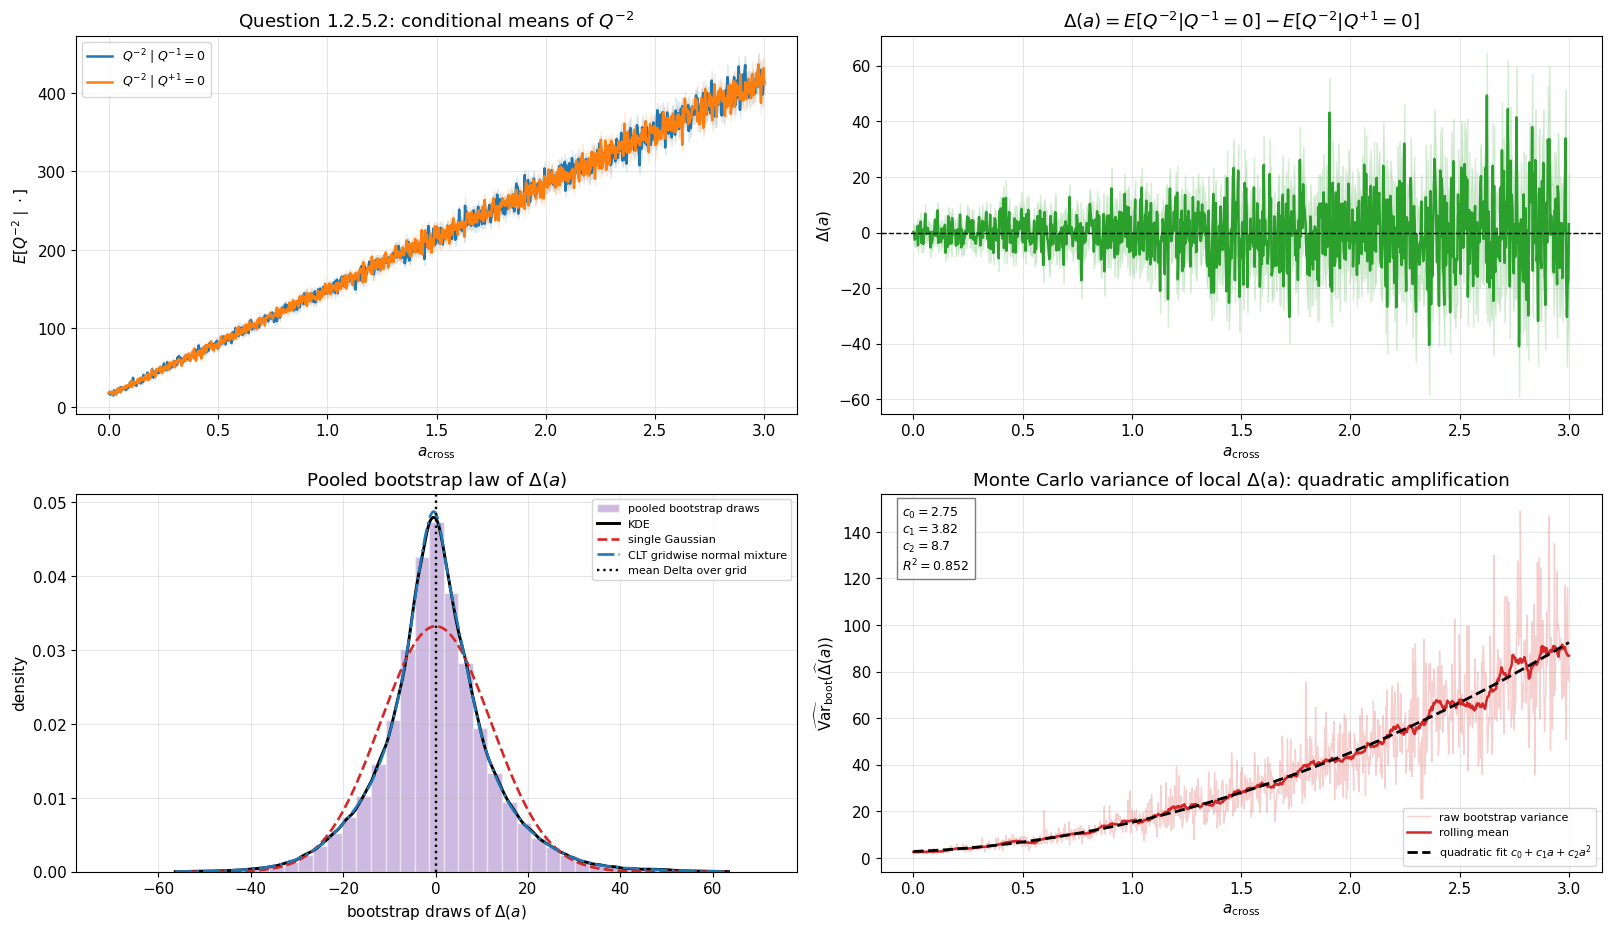

In [17]:
plot_delta_sweep_four_panel(title_prefix='Question 1.2.5.2')

In [18]:
q1252_summary = question_1252_delta_summary.iloc[0]
q1252_density = question_1252_density_diagnostics.iloc[0]
q1252_quad = question_1252_quadratic_variance_fit.iloc[0]
q1252_a0 = question_1252_delta_table.iloc[(question_1252_delta_table['a_cross'] - 0.0).abs().argmin()]
q1252_amax = question_1252_delta_table.iloc[(question_1252_delta_table['a_cross'] - DENSE_A_MAX).abs().argmin()]
visible_dense = question_1252_delta_table[(question_1252_delta_table['delta_mean'] > 0) & (question_1252_delta_table['significant'])]
visible_count = int(len(visible_dense))
visible_range = (float(visible_dense['a_cross'].min()), float(visible_dense['a_cross'].max())) if visible_count else None
fit_sentence = 'le mélange normal local décrit beaucoup mieux la densité que la normale unique' if q1252_density.L1_KDE_vs_gridwise_normal_mixture < q1252_density.L1_KDE_vs_single_normal else 'la normale unique suffit presque autant que le mélange local'

display_fr(
    fr"""
**Réponse à la question 1.2.5.2.** Le balayage dense utilise {int(q1252_summary.n_a_grid)} valeurs de $a_{{cross}}$ entre {q1252_summary.a_min:.1f} et {q1252_summary.a_max:.1f}.
Sur cette grille, la moyenne de $\Delta(a)=E[Q^{{-2}}\mid Q^{{-1}}=0]-E[Q^{{-2}}\mid Q^{{+1}}=0]$ vaut {q1252_summary.mean_delta_over_grid:.2f}, avec variance {q1252_summary.variance_delta_over_grid:.2f} et médiane {q1252_summary.median_delta_over_grid:.2f}.
Au point $a=0$, on obtient $\Delta(0)={q1252_a0.delta_mean:.2f}$; au point $a={DENSE_A_MAX:.1f}$, $\Delta(a)={q1252_amax.delta_mean:.2f}$.
Le nombre de points où $\Delta(a)>0$ et dont l'IC bootstrap exclut zéro est {visible_count}{f', avec $a$ approximativement entre {visible_range[0]:.3f} et {visible_range[1]:.3f}' if visible_range else ''}.
La distribution pooled bootstrap de $\Delta(a)$ est un mélange empirique de lois approximativement normales : {fit_sentence}. Cela est cohérent avec l'idée que, pour chaque $a$, une différence de moyennes bootstrap est localement quasi normale, mais que le pooling sur toute la grille produit une loi de mélange.
La variance bootstrap locale est ajustée par $v(a)=c_0+c_1a+c_2a^2$ avec $c_2={q1252_quad.c2:.3g}$ et $R^2={q1252_quad.R2:.3f}$. Ce coefficient $c_2$ est interprété comme un proxy empirique de l'amplification quadratique, pas comme une estimation exacte de $\operatorname{{Var}}(I_T)$.
"""
)


**Réponse à la question 1.2.5.2.** Le balayage dense utilise 1000 valeurs de $a_{cross}$ entre 0.0 et 3.0.
Sur cette grille, la moyenne de $\Delta(a)=E[Q^{-2}\mid Q^{-1}=0]-E[Q^{-2}\mid Q^{+1}=0]$ vaut 0.03, avec variance 109.82 et médiane -0.21.
Au point $a=0$, on obtient $\Delta(0)=0.20$; au point $a=3.0$, $\Delta(a)=3.01$.
Le nombre de points où $\Delta(a)>0$ et dont l'IC bootstrap exclut zéro est 146, avec $a$ approximativement entre 0.033 et 2.985.
La distribution pooled bootstrap de $\Delta(a)$ est un mélange empirique de lois approximativement normales : le mélange normal local décrit beaucoup mieux la densité que la normale unique. Cela est cohérent avec l'idée que, pour chaque $a$, une différence de moyennes bootstrap est localement quasi normale, mais que le pooling sur toute la grille produit une loi de mélange.
La variance bootstrap locale est ajustée par $v(a)=c_0+c_1a+c_2a^2$ avec $c_2=8.7$ et $R^2=0.852$. Ce coefficient $c_2$ est interprété comme un proxy empirique de l'amplification quadratique, pas comme une estimation exacte de $\operatorname{Var}(I_T)$.


## Synthèse finale alignée avec le sujet

- **Question 1.2.5.1.** Le cas $a=0$ correspond aux deuxièmes limites constantes. Les deux distributions principales demandées ici sont $Q^{-2}\mid Q^{-1}=0$ et $Q^{-2}\mid Q^{+1}=0$, simulées dans `constant_second_limit_table`. Les lois de $Q^{+2}$ ne servent qu'au contrôle de symétrie ask/bid.
- **Question 1.2.5.2.** Le cas $a>0$ active l'excitation des arrivées de deuxième limite par les retraits de première limite. La réponse finale utilise le balayage dense de `1.2.5.0(k)`, avec 1000 valeurs de $a_{cross}$, et mesure
  $$\Delta(a)=E[Q^{-2}\mid Q^{-1}=0]-E[Q^{-2}\mid Q^{+1}=0].$$
- La distribution pooled bootstrap de $\Delta(a)$ doit être lue comme un mélange empirique de lois approximativement normales, pas comme une loi normale unique. La comparaison KDE / normale unique / mélange normal local montre que le mélange local représente mieux la densité.
- La section **1.2.5.0** sert de socle méthodologique : elle explique pourquoi MCRS est utilisé, comment les checkpoints conservent l'état markovien complet $(Q,S)$, et pourquoi les comparaisons doivent porter sur des métriques distributionnelles quand les probabilités Bernoulli sont dégénérées.